<a href="https://colab.research.google.com/github/Marcin19721205/WSBNeuronowe/blob/main/PROJEKT_SIECI_NEURONOWE_20251227.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Grupa projektowa: Marcin Jabłoński / Marta Niebrzegowska

* Problem klasyfikacyjny - biblioteka cifar10

### Spis treści:
1. [Import bibliotek](#0)
2. [Zbiór danych Cifar](#1)
3. [Standaryzacja](#2)
4. [Augmentacja](#4)
6. [Spłaszczenie do modeli ML](#5)
7. [Wariancja skumulowana PCA](#6)
8. [Model PCA dla n=256](#7)
9. [Model Regresji Logistycznej - inicjalizacyjny](#8)
10. [Model SVC - inicjalizacyjny](#9)
11. [Przygotowanie wycinka danych do tuningu RL/SVC](#10)
12. [Tuner — Logistic Regression (PCA=256) - 9 fitów](#11)
13. [Tuner — SVC (LinearSVC, bo klasyczny SVC z RBF na 50k za wolno) - 9 fits](#12)
14. [Regresja Logistyczna - na najlepszych parametrach](#13)
15. [SVC - Na najlepszych parametrach](#14)
16. [Podsumowanie Regresji Logistycznej (Init / best param) + SVC (Initial/ best param) ](#15)
17. [Siec neuronowa CNN first guess) ](#16)
18. [Traning sieci na danych wejściowych bez spłaszczania](#17)
19. [xxx](#18)
20. [xxx](#19)


### <a name='0'></a> 1. Import bibliotek

In [2]:
#Import wymaganych bibliotek

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

np.set_printoptions(precision=4, suppress=True, linewidth=150)

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.decomposition import PCA

### <a name='1'></a> 2. Zbiór danych Cifar10

In [4]:
# wczytanie CIFAR10 z podziałem danych na dane treningowe, testowe.
# Dane wczytane jako RAW: w projekcie zastosowano nazewnictwo danych pozwalające w łatwy sposób tworzyć podsumowania i raporty.
#CIFAR10 posiada 50k

(cifar10_X_train_raw, cifar10_y_train_raw), (cifar10_X_test_raw, cifar10_y_test_raw) = cifar10.load_data()

print("cifar10_X_train_raw:", cifar10_X_train_raw.shape)
print("cifar10_y_train_raw:", cifar10_y_train_raw.shape)
print("cifar10_X_test_raw:", cifar10_X_test_raw.shape)
print("cifar10_y_test_raw:", cifar10_y_test_raw.shape)

# spłaszczenie etyiet do wektora 1D
cifar10_y_train = cifar10_y_train_raw.reshape(-1)
cifar10_y_test  = cifar10_y_test_raw.reshape(-1)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
cifar10_X_train_raw: (50000, 32, 32, 3)
cifar10_y_train_raw: (50000, 1)
cifar10_X_test_raw: (10000, 32, 32, 3)
cifar10_y_test_raw: (10000, 1)


Statystyka danych, sprawdzenie czy dane są pełne i czy mają odpowiedni typ, liczność klas

In [8]:
# Statystyka danych X
def cifar10_stats_X(name, X):
    Xf = X.astype(np.float32)
    print(f"\n{name}")
    print("  shape:", X.shape, "| dtype:", X.dtype)
    print("  min/max :", float(Xf.min()), float(Xf.max()))
    print("  mean/std:", float(Xf.mean()), float(Xf.std()))
    print("  q01/q50/q99:",
          float(np.quantile(Xf, 0.01)),
          float(np.quantile(Xf, 0.50)),
          float(np.quantile(Xf, 0.99)))
    # per-kanał RGB (dla (N,H,W,3))
    if Xf.ndim == 4 and Xf.shape[-1] == 3:
        ch_mean = Xf.mean(axis=(0,1,2))
        ch_std  = Xf.std(axis=(0,1,2))
        print("  RGB mean:", ch_mean)
        print("  RGB std :", ch_std)
    print("  NaN/Inf :", int(np.isnan(Xf).sum()), "/", int(np.isinf(Xf).sum()))

cifar10_stats_X("cifar10_X_train_raw", cifar10_X_train_raw)
cifar10_stats_X("cifar10_X_test_raw",  cifar10_X_test_raw)

# Statystyka y (etykiety)
def cifar10_stats_y(name, y):
    yv = np.asarray(y).reshape(-1)
    uniq, cnt = np.unique(yv, return_counts=True)
    print(f"\n{name}")
    print("  shape:", yv.shape, "| dtype:", yv.dtype)
    print("  min/max:", int(yv.min()), int(yv.max()))
    print("  counts :", dict(zip(uniq.tolist(), cnt.tolist())))
    print("  props  :", dict(zip(uniq.tolist(), (cnt/len(yv)).round(4).tolist())))

cifar10_stats_y("cifar10_y_train", cifar10_y_train)
cifar10_stats_y("cifar10_y_test",  cifar10_y_test)




cifar10_X_train_raw
  shape: (50000, 32, 32, 3) | dtype: uint8
  min/max : 0.0 255.0
  mean/std: 120.70748138427734 64.1500244140625
  q01/q50/q99: 5.0 117.0 254.0
  RGB mean: [125.3069 122.9501 113.866 ]
  RGB std : [62.9933 62.0886 66.705 ]
  NaN/Inf : 0 / 0

cifar10_X_test_raw
  shape: (10000, 32, 32, 3) | dtype: uint8
  min/max : 0.0 255.0
  mean/std: 121.5293197631836 64.06092834472656
  q01/q50/q99: 5.0 117.0 254.0
  RGB mean: [126.0243 123.7084 114.8544]
  RGB std : [62.8964 61.9375 66.7061]
  NaN/Inf : 0 / 0

cifar10_y_train
  shape: (50000,) | dtype: uint8
  min/max: 0 9
  counts : {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 5000, 6: 5000, 7: 5000, 8: 5000, 9: 5000}
  props  : {0: 0.1, 1: 0.1, 2: 0.1, 3: 0.1, 4: 0.1, 5: 0.1, 6: 0.1, 7: 0.1, 8: 0.1, 9: 0.1}

cifar10_y_test
  shape: (10000,) | dtype: uint8
  min/max: 0 9
  counts : {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}
  props  : {0: 0.1, 1: 0.1, 2: 0.1, 3: 0.1, 4: 0.1, 

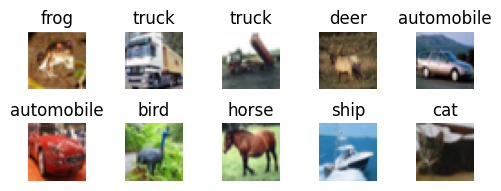

In [18]:
# szybki podgląd obrazków - pierwsze 10
#obrazki są niskiej jakości z dużą ilością szczegółów, więc klasyfikacja będzie trudna
cifar10_class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

plt.figure(figsize=(5, 2))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(cifar10_X_train_raw[i+0]) #przesuwam aby obejrzeć dalej
    plt.title(cifar10_class_names[cifar10_y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


### <a name='2'></a> 3. Standaryzacja

normalizacja wejścia dla CNN, żeby uczenie było stabilne i szybsze.

1. Zamieniam obrazy na float32 i skaluje piksele z [0..255] - Wartośc dla składowych R,G,B → [0..1]. To redukuje duże zakresy wartości i pomaga optymalizatorowi (mniej problemów z gradientami).

2. Liczę średnią i odchylenie standardowe osobno dla kanałów RGB na zbiorze treningowym (po wszystkich obrazach i pikselach). Dzięki temu każdy kanał ma własną statystykę (R, G, B mają identycznego rozkładu).

3. Standaryzacja per kanał: (x - mean) / std, czyli dla train dostaje w przybliżeniu mean≈0, std≈1 na każdym kanale. To zwykle przyspiesza zbieżność i poprawia stabilność.

4. Test standaryzuje tym samym mean/std z train, żeby nie było data leakage (żadnego “podglądania” testu podczas przygotowania danych). +1e-7 to bezpiecznik przed dzieleniem przez zero (praktycznie: “żeby się nie wywaliło, jak statystyki są ekstremalne”).

In [19]:
"""
Skaluje obrazy do zakresu [0,1] (float32), i standaryzuje każdy kanał RGB osobno do mniej więcej mean≈0, std≈1. w celu stabilniejszego i lepszego uczenia (mniej problemów z gradientami i lepsza kondycja danych dla optymalizatora). Statystyki mean/std liczy wyłącznie na train i stosuje je też do testu, żeby nie było data leakage (czyli „podglądania” testu)
"""

# skalowanie + standaryzacja per-kanał (train)
cifar10_X_train_scaled = cifar10_X_train_raw.astype(np.float32) / 255.0  # konwersja na float32 + skalowanie pikseli z [0..255] do [0..1]

cifar10_X_test_scaled  = cifar10_X_test_raw.astype(np.float32) / 255.0   # to samo dla testu; ujednolica zakres i stabilizuje uczenie (mniej “rozjechanych” gradientów)

# mean/std po (N,H,W) osobno dla kanałów RGB
cifar10_mean_ch = cifar10_X_train_scaled.mean(axis=(0, 1, 2), keepdims=True)  # średnia osobno dla R,G,B po całym zbiorze treningowym (po N,H,W)
cifar10_std_ch  = cifar10_X_train_scaled.std(axis=(0, 1, 2), keepdims=True) + 1e-7  # odchylenie std dla R,G,B; +1e-7 to bezpiecznik, żeby nie dzielić przez 0

cifar10_X_train_std = (cifar10_X_train_scaled - cifar10_mean_ch) / cifar10_std_ch  # standaryzacja train: każdemu kanałowi nadajesz mean≈0 i std≈1 (szybsza, stabilniejsza optymalizacja)
cifar10_X_test_std  = (cifar10_X_test_scaled  - cifar10_mean_ch) / cifar10_std_ch  # standaryzacja testu TYM SAMYM mean/std z train (żadnego “podglądania” testu → brak data leakage)

print("mean RGB:", cifar10_mean_ch.reshape(-1))     # wypisuje 3 wartości średnich dla kanałów: [mean_R, mean_G, mean_B] (reshape(-1) spłaszcza do 1D)
print("std  RGB:", cifar10_std_ch.reshape(-1))      # wypisuje 3 wartości odchyleń std dla kanałów: [std_R, std_G, std_B]
print("train std shape:", cifar10_X_train_std.shape) # kontrola kształtu po przekształceniach (powinno zostać N×H×W×3)


mean RGB: [0.4914 0.4822 0.4465]
std  RGB: [0.247  0.2435 0.2616]
train std shape: (50000, 32, 32, 3)


In [20]:
# Podsumowanie + statystyka cifar10_X_test_scaled (NumPy: N×H×W×3)

print("shape test:", cifar10_X_test_scaled.shape)
print("dtype test:", cifar10_X_test_scaled.dtype)

print("shape train:", cifar10_X_train_scaled.shape)
print("dtype train:", cifar10_X_train_scaled.dtype)


# globalnie (cały tensor)
print("global min/max :", float(cifar10_X_test_scaled.min()), float(cifar10_X_test_scaled.max()))
print("global mean/std:", float(cifar10_X_test_scaled.mean()), float(cifar10_X_test_scaled.std()))
print("global q01/q50/q99:",
      float(np.quantile(cifar10_X_test_scaled, 0.01)),
      float(np.quantile(cifar10_X_test_scaled, 0.50)),
      float(np.quantile(cifar10_X_test_scaled, 0.99)))

# per-kanał RGB (po N,H,W)
ch_min  = cifar10_X_test_scaled.min(axis=(0, 1, 2))
ch_max  = cifar10_X_test_scaled.max(axis=(0, 1, 2))
ch_mean = cifar10_X_test_scaled.mean(axis=(0, 1, 2))
ch_std  = cifar10_X_test_scaled.std(axis=(0, 1, 2))

ch_q01 = np.quantile(cifar10_X_test_scaled, 0.01, axis=(0, 1, 2))
ch_q50 = np.quantile(cifar10_X_test_scaled, 0.50, axis=(0, 1, 2))
ch_q99 = np.quantile(cifar10_X_test_scaled, 0.99, axis=(0, 1, 2))

print("\nRGB min :", ch_min)
print("RGB max :", ch_max)
print("RGB mean:", ch_mean)
print("RGB std :", ch_std)
print("RGB q01 :", ch_q01)
print("RGB q50 :", ch_q50)
print("RGB q99 :", ch_q99)

# sanity-check: ile NaN/Inf
print("\nNaN count:", int(np.isnan(cifar10_X_test_scaled).sum()))
print("Inf count:", int(np.isinf(cifar10_X_test_scaled).sum()))


shape test: (10000, 32, 32, 3)
dtype test: float32
shape train: (50000, 32, 32, 3)
dtype train: float32
global min/max : 0.0 1.0
global mean/std: 0.4765852391719818 0.25121963024139404
global q01/q50/q99: 0.019607843831181526 0.4588235318660736 0.9960784316062927

RGB min : [0. 0. 0.]
RGB max : [1. 1. 1.]
RGB mean: [0.4942 0.4851 0.4504]
RGB std : [0.2467 0.2429 0.2616]
RGB q01 : [0.0196 0.0235 0.0196]
RGB q50 : [0.4863 0.4745 0.4118]
RGB q99 : [0.9961 0.9961 0.9961]

NaN count: 0
Inf count: 0


Podsumowania zmiennych, aby upewnić się że nie ma NaN itd

In [21]:
# Podsumowanie + statystyka cifar10_X_train_scaled (NumPy: N×H×W×3)

print("shape:", cifar10_X_train_scaled.shape)
print("dtype:", cifar10_X_train_scaled.dtype)

# globalnie (cały tensor)
print("global min/max :", float(cifar10_X_train_scaled.min()), float(cifar10_X_train_scaled.max()))
print("global mean/std:", float(cifar10_X_train_scaled.mean()), float(cifar10_X_train_scaled.std()))
print("global q01/q50/q99:",
      float(np.quantile(cifar10_X_train_scaled, 0.01)),
      float(np.quantile(cifar10_X_train_scaled, 0.50)),
      float(np.quantile(cifar10_X_train_scaled, 0.99)))

# per-kanał RGB (po N,H,W)
ch_min  = cifar10_X_train_scaled.min(axis=(0, 1, 2))
ch_max  = cifar10_X_train_scaled.max(axis=(0, 1, 2))
ch_mean = cifar10_X_train_scaled.mean(axis=(0, 1, 2))
ch_std  = cifar10_X_train_scaled.std(axis=(0, 1, 2))

ch_q01 = np.quantile(cifar10_X_train_scaled, 0.01, axis=(0, 1, 2))
ch_q50 = np.quantile(cifar10_X_train_scaled, 0.50, axis=(0, 1, 2))
ch_q99 = np.quantile(cifar10_X_train_scaled, 0.99, axis=(0, 1, 2))

print("\nRGB min :", ch_min)
print("RGB max :", ch_max)
print("RGB mean:", ch_mean)
print("RGB std :", ch_std)
print("RGB q01 :", ch_q01)
print("RGB q50 :", ch_q50)
print("RGB q99 :", ch_q99)

# sanity-check: ile NaN/Inf (czasem ktoś się potknie i potem jest płacz)
print("\nNaN count:", int(np.isnan(cifar10_X_train_scaled).sum()))
print("Inf count:", int(np.isinf(cifar10_X_train_scaled).sum()))


shape: (50000, 32, 32, 3)
dtype: float32
global min/max : 0.0 1.0
global mean/std: 0.4733648896217346 0.25156906247138977
global q01/q50/q99: 0.019607843831181526 0.4588235318660736 0.9960784316062927

RGB min : [0. 0. 0.]
RGB max : [1. 1. 1.]
RGB mean: [0.4914 0.4822 0.4465]
RGB std : [0.247  0.2435 0.2616]
RGB q01 : [0.0196 0.0196 0.0157]
RGB q50 : [0.4824 0.4745 0.4078]
RGB q99 : [0.9961 0.9961 1.    ]

NaN count: 0
Inf count: 0


### <a name='4'></a> 4. Augmentacja

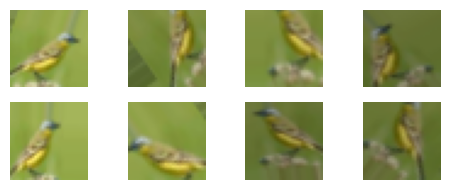

label id: 2 -> label name: bird


In [24]:
# Augumentacja - prezentacja działania
# augmentacja CIFAR10 + podgląd (pewna wersja: RAW uint8 + rescale)

# generator augmentacji -> numer obrazka
#
n=1129 #numer obrazka
#
#
cifar10_datagen_aug = ImageDataGenerator(
    rescale=1.0/255.0,          # RAW 0..255 -> float 0..1
    width_shift_range=0.3,
    height_shift_range=0.3,
    rotation_range=45,
    brightness_range=[0.7, 1.3],
    zoom_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)

# iterator dla wybranego obrazu
cifar10_x0_raw = cifar10_X_train_raw[n]                 # (32,32,3) uint8, [numer obrazka]
cifar10_it = cifar10_datagen_aug.flow(
    np.expand_dims(cifar10_x0_raw, axis=0),             # (1,32,32,3)
    batch_size=1,
    shuffle=False,
    seed=123
)

# podgląd 8 augmentacji
plt.figure(figsize=(5, 2))
for i in range(8):
    x_aug = next(cifar10_it)[0]                         # (32,32,3) float w [0..1]
    plt.subplot(2, 4, i + 1)
    plt.imshow(np.clip(x_aug, 0.0, 1.0))
    plt.axis("off")

plt.tight_layout()
plt.show()

# dla obrazka: numer etykiety + nazwa
cifar10_y0 = int(np.squeeze(cifar10_y_train_raw[n]))
cifar10_class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
print("label id:", cifar10_y0, "->", "label name:", cifar10_class_names[cifar10_y0])




Augmentacja własciwa - przekształcone obrazki dodajemy tylko do train dodajemy do train

In [26]:
# --- AUGMENTACJA -> DODANIE DO TRAIN (bez _use, nadpisujemy cifar10_X_train_std / cifar10_y_train) ---

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

cifar10_aug_n_extra = 50000 # ilość dodatkowych elementów z augmentacji 50000 => 0 bez dodawania czegokolwiek
cifar10_aug_batch   = 256
cifar10_aug_seed    = 123

cifar10_datagen_aug = ImageDataGenerator(
    rescale=1.0/255.0,
    width_shift_range=0.3,
    height_shift_range=0.3,
    rotation_range=45,
    brightness_range=[0.7, 1.3],
    zoom_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)

cifar10_it_aug = cifar10_datagen_aug.flow(
    cifar10_X_train_raw,     # RAW uint8
    cifar10_y_train,         # etykiety (N,) lub one-hot
    batch_size=cifar10_aug_batch,
    shuffle=True,
    seed=cifar10_aug_seed
)

# bufory na augmenty (najpierw [0..1])
cifar10_X_train_aug_scaled = np.empty((cifar10_aug_n_extra, 32, 32, 3), dtype=np.float32)
cifar10_y_train_aug_extra  = np.empty((cifar10_aug_n_extra,), dtype=np.int64)

cifar10_filled = 0
while cifar10_filled < cifar10_aug_n_extra:
    x_batch_scaled, y_batch = next(cifar10_it_aug)

    if y_batch.ndim > 1:
        y_batch = np.argmax(y_batch, axis=1)

    take = min(len(x_batch_scaled), cifar10_aug_n_extra - cifar10_filled)

    cifar10_X_train_aug_scaled[cifar10_filled:cifar10_filled + take] = x_batch_scaled[:take]
    cifar10_y_train_aug_extra[cifar10_filled:cifar10_filled + take]  = y_batch[:take]

    cifar10_filled += take

# standaryzacja augmentów tym samym mean/std co train (bez data leakage)
cifar10_X_train_aug_std = (cifar10_X_train_aug_scaled - cifar10_mean_ch) / cifar10_std_ch

# DOŁĄCZENIE augmentów do TRAIN (nadpisujemy główne zmienne, żeby pipeline był spójny)
cifar10_X_train_std = np.concatenate([cifar10_X_train_std, cifar10_X_train_aug_std], axis=0)
cifar10_y_train     = np.concatenate([cifar10_y_train,     cifar10_y_train_aug_extra], axis=0)

# mieszanie train (żeby org/aug nie leżały blokami)
cifar10_rng  = np.random.default_rng(cifar10_aug_seed)
cifar10_perm = cifar10_rng.permutation(cifar10_X_train_std.shape[0])
cifar10_X_train_std = cifar10_X_train_std[cifar10_perm]
cifar10_y_train     = cifar10_y_train[cifar10_perm]

print("X_train_std (po aug):", cifar10_X_train_std.shape)
print("y_train     (po aug):", cifar10_y_train.shape)
print("X_test_std  (bez aug):", cifar10_X_test_std.shape)


X_train_std (po aug): (100000, 32, 32, 3)
y_train     (po aug): (100000,)
X_test_std  (bez aug): (10000, 32, 32, 3)


### <a name='5'></a> 5. Spłaszczenie do modeli ML


! Uwaga - do CNN nie spłaszczamy - CNN musi mieć wejście H×W×C = 32×32×3 [pixel x pixel x RGB]

Dane standryzowane - nie spłaszczone

cifar10_X_train_std

cifar10_y_train

Spłaszczanie, żeby zamienić obraz (H×W×C) na jeden wektor cech, czyli format (N, D).

Większość klasycznych modeli ML (LogReg, SVM, kNN, drzewa, PCA itd.) oczekuje tablicy 2D: wiersz = próbka, kolumny = cechy. Obraz 4D (N,H,W,C) nie pasuje do modelu

reshape(N, -1) robi z każdego obrazka wektor długości 32·32·3 = 3072 (dla CIFAR-10), więc wynikowo (N, 3072).

Uwaga: tracimy strukturę przestrzenną (relacje sąsiedztwa pikseli)

In [27]:
# Komórka 1 — spłaszczenie obrazów pod modele (N, 32*32*3)
#
# Splaszczenie dajemy do ML, ale bez sieci CNN, tam musi być H - Height, W - Width, C - Channel
cifar10_X_train_flat = cifar10_X_train_std.reshape(cifar10_X_train_std.shape[0], -1)
cifar10_X_test_flat  = cifar10_X_test_std.reshape(cifar10_X_test_std.shape[0],  -1)

print("cifar10_X_train_flat:", cifar10_X_train_flat.shape)
print("cifar10_X_test_flat :", cifar10_X_test_flat.shape)


cifar10_X_train_flat: (100000, 3072)
cifar10_X_test_flat : (10000, 3072)


### <a name='6'></a> 6. Wariancja skumulowana do PCA


Obliczenie wariancji skumulowanej dla PCA na danych spłaszczonych

Przed PCA są dane spłaszczone cifar10_X_train_flat o wymiarze D = 32·32·3 = 3072 cech na obrazek, czyli kształt (N, 3072).

In [28]:
# Dla każdego wariantu dopasowuje PCA tylko na train, transformuje train i test, zapisuje wyniki oraz sumę wyjaśnionej wariancji # do słownika.

# PCA: kilka wariantów n_components + zapis do słownika (pod porównania)
from sklearn.decomposition import PCA

cifar10_pca_components_list = [64, 128, 256, 512]  # warianty do porównania
cifar10_pca_bundle = {}  # tu trzymamy: model PCA + transformacje + explained variance

for cifar10_pca_n in cifar10_pca_components_list:
    cifar10_pca_model = PCA(n_components=cifar10_pca_n, random_state=123)

    cifar10_X_train_pca = cifar10_pca_model.fit_transform(cifar10_X_train_flat)  # fit tylko na train
    cifar10_X_test_pca  = cifar10_pca_model.transform(cifar10_X_test_flat)

    cifar10_pca_bundle[cifar10_pca_n] = {
        "pca_model": cifar10_pca_model,
        "X_train_pca": cifar10_X_train_pca,
        "X_test_pca": cifar10_X_test_pca,
        "explained_var_sum": float(cifar10_pca_model.explained_variance_ratio_.sum()),
    }

    print(f"PCA={cifar10_pca_n}: X_train_pca={cifar10_X_train_pca.shape}, explained_sum={cifar10_pca_bundle[cifar10_pca_n]['explained_var_sum']:.4f}")


PCA=64: X_train_pca=(100000, 64), explained_sum=0.8882
PCA=128: X_train_pca=(100000, 128), explained_sum=0.9348
PCA=256: X_train_pca=(100000, 256), explained_sum=0.9680
PCA=512: X_train_pca=(100000, 512), explained_sum=0.9880


In [30]:
# Wykres wariancji PCA j (bar + cumulative line) dla wybranego n_components

import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Wariant PCA (musi istnieć w cifar10_pca_bundle)
cifar10_pca_n_plot = 512 #dla jakiej ilości wymiarów PCA ma zostać stworzony wykres

cifar10_pca_model_plot = cifar10_pca_bundle[cifar10_pca_n_plot]["pca_model"]
cifar10_ev_ratio = cifar10_pca_model_plot.explained_variance_ratio_
cifar10_ev_cum = np.cumsum(cifar10_ev_ratio)

cifar10_pca_var_df = pd.DataFrame({
    "component": np.arange(1, len(cifar10_ev_ratio) + 1),
    "explained_variance_ratio": cifar10_ev_ratio,
    "cumulative": cifar10_ev_cum
})

fig = go.Figure(data=[
    go.Bar(
        x=cifar10_pca_var_df["component"],
        y=cifar10_pca_var_df["explained_variance_ratio"],
        name="explained_variance_ratio"
    ),
    go.Scatter(
        x=cifar10_pca_var_df["component"],
        y=cifar10_pca_var_df["cumulative"],
        mode="lines+markers",
        name="cumulative",
        yaxis="y2"
    )
])

fig.update_layout(
    title=f"CIFAR10 — PCA wariancja (n_components={cifar10_pca_n_plot})",
    template="plotly_dark",
    width=950,
    height=550,
    xaxis=dict(title="component"),
    yaxis=dict(title="explained_variance_ratio"),
    yaxis2=dict(
        title="cumulative",
        overlaying="y",
        side="right",
        range=[0, 1.0]
    ),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

# tabela jak na screenie:
cifar10_pca_var_df.head(10)


,component,explained_variance_ratio,cumulative
0,1,0.331052,0.331052
1,2,0.111943,0.442994
2,3,0.057509,0.500504
3,4,0.052988,0.553492
4,5,0.036390,0.589881
5,6,0.026605,0.616487
6,7,0.025084,0.641570
7,8,0.022344,0.663914
8,9,0.015489,0.679403
9,10,0.015321,0.694724


Struktura jak wygląda PCA dla 2 i 3 wymiarów danych wejściowych

In [31]:
# CA do wizualizacji (2D i 3D) + sampling

from sklearn.decomposition import PCA

cifar10_class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

# spłaszcz pod PCA
cifar10_X_train_flat = cifar10_X_train_std.reshape(cifar10_X_train_std.shape[0], -1)

# sampling do plotów (żeby Plotly nie umarł)
cifar10_viz_n = 5000
rng = np.random.default_rng(123)
cifar10_viz_idx = rng.choice(cifar10_X_train_flat.shape[0], size=cifar10_viz_n, replace=False)

cifar10_X_train_flat_viz = cifar10_X_train_flat[cifar10_viz_idx]
cifar10_y_train_viz = cifar10_y_train[cifar10_viz_idx]

# PCA 2D i 3D (tylko pod wykresy)
cifar10_pca_viz2_model = PCA(n_components=2, random_state=123)
cifar10_X_train_pca2_viz = cifar10_pca_viz2_model.fit_transform(cifar10_X_train_flat_viz)

cifar10_pca_viz3_model = PCA(n_components=3, random_state=123)
cifar10_X_train_pca3_viz = cifar10_pca_viz3_model.fit_transform(cifar10_X_train_flat_viz)

print("PCA2 explained_sum:", float(cifar10_pca_viz2_model.explained_variance_ratio_.sum()))
print("PCA3 explained_sum:", float(cifar10_pca_viz3_model.explained_variance_ratio_.sum()))


PCA2 explained_sum: 0.44198107719421387
PCA3 explained_sum: 0.4998731315135956


In [32]:
# PCA 2D scatter (Plotly)
# PCA dla PCA1/PCA2 - 2 wymiary

import pandas as pd
import plotly.express as px

cifar10_pca2_df = pd.DataFrame({
    "pca_1": cifar10_X_train_pca2_viz[:, 0],
    "pca_2": cifar10_X_train_pca2_viz[:, 1],
    "class_id": cifar10_y_train_viz
})
cifar10_pca2_df["class_name"] = cifar10_pca2_df["class_id"].map(lambda k: cifar10_class_names[int(k)])

fig = px.scatter(
    cifar10_pca2_df,
    x="pca_1", y="pca_2",
    color="class_name",
    opacity=0.55,
    template="plotly_dark",
    width=1000, height=600,
    title="CIFAR10 — PCA 2D (2 wymiary PCA1/PCA2)"
)
fig.show()


In [33]:
# PCA 3D scatter (Plotly)
# PCA dla PCA1/PCA2/PCA3 - 3 wymiary

cifar10_pca3_df = pd.DataFrame({
    "pca_1": cifar10_X_train_pca3_viz[:, 0],
    "pca_2": cifar10_X_train_pca3_viz[:, 1],
    "pca_3": cifar10_X_train_pca3_viz[:, 2],
    "class_id": cifar10_y_train_viz
})
cifar10_pca3_df["class_name"] = cifar10_pca3_df["class_id"].map(lambda k: cifar10_class_names[int(k)])

fig = px.scatter_3d(
    cifar10_pca3_df,
    x="pca_1", y="pca_2", z="pca_3",
    color="class_name",
    opacity=0.60,
    template="plotly_dark",
    width=1000, height=700,
    title="CIFAR10 — PCA 3D (sample)"
)
fig.show()


### <a name='7'></a> 7. Model PCA dla 256 wymiarów (97% accuracy)


In [34]:
#wybór wariantu PCA=256 + wygodne skróty do danych
cifar10_pca_n_final = 256

cifar10_pca_final_model = cifar10_pca_bundle[cifar10_pca_n_final]["pca_model"]
cifar10_X_train_pca_256 = cifar10_pca_bundle[cifar10_pca_n_final]["X_train_pca"]
cifar10_X_test_pca_256  = cifar10_pca_bundle[cifar10_pca_n_final]["X_test_pca"]

cifar10_pca_256_ev_sum = cifar10_pca_bundle[cifar10_pca_n_final]["explained_var_sum"]

print("cifar10_X_train_pca_256:", cifar10_X_train_pca_256.shape)
print("cifar10_X_test_pca_256 :", cifar10_X_test_pca_256.shape)
print("explained_var_sum:", cifar10_pca_256_ev_sum)


cifar10_X_train_pca_256: (100000, 256)
cifar10_X_test_pca_256 : (10000, 256)
explained_var_sum: 0.9679840803146362


### <a name='8'></a> 8. Model Regresji Logistycznej - inicjalizacyjny


In [35]:
#PCA=256 + Logistic Regression (pełny run)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import plotly.express as px

# model
cifar10_clf_pca_256_lr = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=300,
    n_jobs=-1,
    random_state=123
)

# trening
cifar10_clf_pca_256_lr.fit(cifar10_X_train_pca_256, cifar10_y_train)

# predykcja
cifar10_y_pred_pca_256_lr = cifar10_clf_pca_256_lr.predict(cifar10_X_test_pca_256)

# metryki
cifar10_acc_pca_256_lr = accuracy_score(cifar10_y_test, cifar10_y_pred_pca_256_lr)
cifar10_f1m_pca_256_lr = f1_score(cifar10_y_test, cifar10_y_pred_pca_256_lr, average="macro")

print("LogReg PCA=256 | accuracy:", cifar10_acc_pca_256_lr)
print("LogReg PCA=256 | f1_macro:", cifar10_f1m_pca_256_lr)
print("\nclassification_report:\n", classification_report(cifar10_y_test, cifar10_y_pred_pca_256_lr, target_names=cifar10_class_names))

# confusion matrix
cifar10_cm_pca_256_lr = confusion_matrix(cifar10_y_test, cifar10_y_pred_pca_256_lr)

cifar10_cm_df_pca_256_lr = pd.DataFrame(
    cifar10_cm_pca_256_lr,
    index=[f"true_{c}" for c in cifar10_class_names],
    columns=[f"pred_{c}" for c in cifar10_class_names]
)

fig = px.imshow(
    cifar10_cm_df_pca_256_lr,
    text_auto=True,
    aspect="auto",
    template="plotly_dark",
    title="CIFAR10 | PCA=256 | Logistic Regression | Confusion Matrix"
)
fig.show()

# pakiet wyników do porównań
cifar10_results_pca_256_lr = {
    "model_name": "LogisticRegression",
    "pca_n": 256,
    "explained_var_sum": cifar10_pca_256_ev_sum,
    "accuracy": float(cifar10_acc_pca_256_lr),
    "f1_macro": float(cifar10_f1m_pca_256_lr),
    "confusion_matrix": cifar10_cm_pca_256_lr,
}
cifar10_results_pca_256_lr


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



LogReg PCA=256 | accuracy: 0.3971
LogReg PCA=256 | f1_macro: 0.38911747848149114

classification_report:
               precision    recall  f1-score   support

    airplane       0.44      0.47      0.45      1000
  automobile       0.39      0.49      0.43      1000
        bird       0.33      0.22      0.27      1000
         cat       0.32      0.19      0.24      1000
        deer       0.41      0.31      0.35      1000
         dog       0.33      0.33      0.33      1000
        frog       0.43      0.48      0.46      1000
       horse       0.43      0.46      0.44      1000
        ship       0.46      0.50      0.48      1000
       truck       0.38      0.51      0.43      1000

    accuracy                           0.40     10000
   macro avg       0.39      0.40      0.39     10000
weighted avg       0.39      0.40      0.39     10000



{'model_name': 'LogisticRegression',
 'pca_n': 256,
 'explained_var_sum': 0.9679840803146362,
 'accuracy': 0.3971,
 'f1_macro': 0.38911747848149114,
 'confusion_matrix': array([[474,  60,  39,  15,  19,  32,  23,  69, 176,  93],
        [ 47, 489,  17,  20,  16,  40,  37,  54,  66, 214],
        [116,  75, 224,  69, 108,  94, 129,  88,  57,  40],
        [ 57,  82,  78, 191,  57, 196, 125,  57,  51, 106],
        [ 62,  55, 101,  42, 312,  91, 127, 127,  36,  47],
        [ 37,  65,  91, 120,  72, 331, 101,  75,  57,  51],
        [ 26,  60,  54,  76,  92,  82, 485,  50,  25,  50],
        [ 42,  77,  60,  31,  69,  78,  42, 456,  40, 105],
        [160,  86,  11,  15,   7,  41,  17,  26, 496, 141],
        [ 68, 201,  14,  11,  18,  15,  36,  48,  76, 513]])}

### <a name='9'></a> 9. Model SVC - inicjalizacyjny


In [36]:
#PCA=256 + Linear SVC (pełny run)

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import plotly.express as px

# model
cifar10_clf_pca_256_svc = LinearSVC(
    C=1.0,
    random_state=123
)

# trening
cifar10_clf_pca_256_svc.fit(cifar10_X_train_pca_256, cifar10_y_train)

# predykcja
cifar10_y_pred_pca_256_svc = cifar10_clf_pca_256_svc.predict(cifar10_X_test_pca_256)

# metryki
cifar10_acc_pca_256_svc = accuracy_score(cifar10_y_test, cifar10_y_pred_pca_256_svc)
cifar10_f1m_pca_256_svc = f1_score(cifar10_y_test, cifar10_y_pred_pca_256_svc, average="macro")

print("LinearSVC PCA=256 | accuracy:", cifar10_acc_pca_256_svc)
print("LinearSVC PCA=256 | f1_macro:", cifar10_f1m_pca_256_svc)
print("\nclassification_report:\n", classification_report(cifar10_y_test, cifar10_y_pred_pca_256_svc, target_names=cifar10_class_names))

# confusion matrix
cifar10_cm_pca_256_svc = confusion_matrix(cifar10_y_test, cifar10_y_pred_pca_256_svc)

cifar10_cm_df_pca_256_svc = pd.DataFrame(
    cifar10_cm_pca_256_svc,
    index=[f"true_{c}" for c in cifar10_class_names],
    columns=[f"pred_{c}" for c in cifar10_class_names]
)

fig = px.imshow(
    cifar10_cm_df_pca_256_svc,
    text_auto=True,
    aspect="auto",
    template="plotly_dark",
    title="CIFAR10 | PCA=256 | LinearSVC | Confusion Matrix"
)
fig.show()

# pakiet wyników do porównań
cifar10_results_pca_256_svc = {
    "model_name": "LinearSVC",
    "pca_n": 256,
    "explained_var_sum": cifar10_pca_256_ev_sum,
    "accuracy": float(cifar10_acc_pca_256_svc),
    "f1_macro": float(cifar10_f1m_pca_256_svc),
    "confusion_matrix": cifar10_cm_pca_256_svc,
}
cifar10_results_pca_256_svc


LinearSVC PCA=256 | accuracy: 0.3914
LinearSVC PCA=256 | f1_macro: 0.37766757036112236

classification_report:
               precision    recall  f1-score   support

    airplane       0.42      0.47      0.45      1000
  automobile       0.36      0.52      0.42      1000
        bird       0.34      0.18      0.23      1000
         cat       0.35      0.14      0.21      1000
        deer       0.43      0.28      0.34      1000
         dog       0.35      0.32      0.33      1000
        frog       0.42      0.50      0.46      1000
       horse       0.42      0.47      0.44      1000
        ship       0.45      0.51      0.48      1000
       truck       0.35      0.53      0.42      1000

    accuracy                           0.39     10000
   macro avg       0.39      0.39      0.38     10000
weighted avg       0.39      0.39      0.38     10000



{'model_name': 'LinearSVC',
 'pca_n': 256,
 'explained_var_sum': 0.9679840803146362,
 'accuracy': 0.3914,
 'f1_macro': 0.37766757036112236,
 'confusion_matrix': array([[471,  68,  17,   9,  13,  25,  25,  72, 188, 112],
        [ 42, 520,  10,  11,  12,  27,  37,  52,  70, 219],
        [133,  90, 176,  45, 101,  90, 144, 105,  65,  51],
        [ 73, 113,  57, 145,  38, 186, 137,  58,  66, 127],
        [ 72,  70,  76,  29, 278,  86, 149, 147,  34,  59],
        [ 40,  92,  76,  87,  60, 322,  96,  90,  71,  66],
        [ 28,  94,  42,  49,  74,  73, 498,  52,  28,  62],
        [ 45,  86,  46,  21,  53,  70,  37, 469,  42, 131],
        [150, 101,   4,   7,   3,  38,  13,  26, 509, 149],
        [ 59, 217,  10,   8,  11,  16,  37,  48,  68, 526]])}


### <a name='10'></a> 10. Przygotowanie wycinka danych do tuningu RL/SVC



In [38]:
# Zbiór do tuningu (stratyfikowany podzbiór train), żeby GridSearch nie zabił runtime
from sklearn.model_selection import train_test_split

cifar10_tune_size =50000  # można zmienić
cifar10_X_train_pca_256_tune, _, cifar10_y_train_tune, _ = train_test_split(
    cifar10_X_train_pca_256,
    cifar10_y_train,
    train_size=cifar10_tune_size,
    random_state=123,
    stratify=cifar10_y_train
)

print("tune X:", cifar10_X_train_pca_256_tune.shape)
print("tune y:", cifar10_y_train_tune.shape)


tune X: (50000, 256)
tune y: (50000,)


### <a name='11'></a> 11. Tuner — Logistic Regression (PCA=256) - 9 fitów


In [39]:
# FAST tuner LR (nadpisuje cifar10_best_params_lr_pca256)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cifar10_cv_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

cifar10_lr_fast = LogisticRegression(
    solver="lbfgs",
    multi_class="multinomial",
    max_iter=300,
    n_jobs=-1,
    random_state=123
)

cifar10_param_grid_lr_fast = {"C": [0.3, 1.0, 3.0]}

cifar10_grid_lr_pca256_fast = GridSearchCV(
    cifar10_lr_fast,
    cifar10_param_grid_lr_fast,
    scoring="f1_macro",
    cv=cifar10_cv_fast,
    n_jobs=-1,
    verbose=2
)

cifar10_grid_lr_pca256_fast.fit(cifar10_X_train_pca_256_tune, cifar10_y_train_tune)

cifar10_best_params_lr_pca256 = cifar10_grid_lr_pca256_fast.best_params_
cifar10_best_score_lr_pca256  = float(cifar10_grid_lr_pca256_fast.best_score_)

print("BEST LR params:", cifar10_best_params_lr_pca256)
print("BEST LR cv f1_macro:", cifar10_best_score_lr_pca256)


Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



BEST LR params: {'C': 0.3}
BEST LR cv f1_macro: 0.22982743808856784


### <a name='12'></a> 12. Tuner — SVC (LinearSVC, bo klasyczny SVC z RBF na 50k za wolno) - 9 fits


In [40]:
#GridSearchCV dla LinearSVC (FAST: 3 foldy, 3 kandydaty = 9 fitów)

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cifar10_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

# bazowy model (loss zostawiamy stałe — default i tak jest 'squared_hinge')
cifar10_svc_base = LinearSVC(
    random_state=123
)

# FAST grid: tylko C (3 kandydaty)
cifar10_param_grid_svc_pca256 = {
    "C": [0.3, 1.0, 3.0]
}

cifar10_grid_svc_pca256 = GridSearchCV(
    estimator=cifar10_svc_base,
    param_grid=cifar10_param_grid_svc_pca256,
    scoring="f1_macro",
    cv=cifar10_cv,
    n_jobs=-1,
    verbose=2
)

cifar10_grid_svc_pca256.fit(cifar10_X_train_pca_256_tune, cifar10_y_train_tune)

cifar10_best_params_svc_pca256 = cifar10_grid_svc_pca256.best_params_
cifar10_best_score_svc_pca256  = float(cifar10_grid_svc_pca256.best_score_)

print("BEST LinearSVC params:", cifar10_best_params_svc_pca256)
print("BEST LinearSVC cv f1_macro:", cifar10_best_score_svc_pca256)


Fitting 3 folds for each of 3 candidates, totalling 9 fits
BEST LinearSVC params: {'C': 0.3}
BEST LinearSVC cv f1_macro: 0.22556387104814848


trenowana Regresja Logisstyczna i SVC na nalepszych parametrach + confusion matrix

### <a name='13'></a> 13. Regresja Logistyczna - na najlepszych parametrach



In [41]:
# PCA=256 + Logistic Regression (BEST z tunera, pełny run)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import plotly.express as px

# BEST param z tunera
cifar10_lr_best_C = 3.0

# model
cifar10_clf_pca_256_lr_best = LogisticRegression(
    C=cifar10_lr_best_C,
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=500,
    n_jobs=-1,
    random_state=123
)

# trening
cifar10_clf_pca_256_lr_best.fit(cifar10_X_train_pca_256, cifar10_y_train)

# predykcja
cifar10_y_pred_pca_256_lr_best = cifar10_clf_pca_256_lr_best.predict(cifar10_X_test_pca_256)

# metryki
cifar10_acc_pca_256_lr_best = accuracy_score(cifar10_y_test, cifar10_y_pred_pca_256_lr_best)
cifar10_f1m_pca_256_lr_best = f1_score(cifar10_y_test, cifar10_y_pred_pca_256_lr_best, average="macro")

print("LogReg PCA=256 | BEST C:", cifar10_lr_best_C)
print("LogReg PCA=256 | accuracy:", cifar10_acc_pca_256_lr_best)
print("LogReg PCA=256 | f1_macro:", cifar10_f1m_pca_256_lr_best)
print("\nclassification_report:\n",
      classification_report(cifar10_y_test, cifar10_y_pred_pca_256_lr_best, target_names=cifar10_class_names))

# confusion matrix
cifar10_cm_pca_256_lr_best = confusion_matrix(cifar10_y_test, cifar10_y_pred_pca_256_lr_best)

cifar10_cm_df_pca_256_lr_best = pd.DataFrame(
    cifar10_cm_pca_256_lr_best,
    index=[f"true_{c}" for c in cifar10_class_names],
    columns=[f"pred_{c}" for c in cifar10_class_names]
)

fig = px.imshow(
    cifar10_cm_df_pca_256_lr_best,
    text_auto=True,
    aspect="auto",
    template="plotly_dark",
    title=f"CIFAR10 | PCA=256 | Logistic Regression (BEST C={cifar10_lr_best_C}) | Confusion Matrix"
)
fig.show()

# pakiet wyników do porównań (BEST)
cifar10_results_pca_256_lr_best = {
    "model_name": "LogisticRegression",
    "pca_n": 256,
    "best_params": {"C": cifar10_lr_best_C},
    "explained_var_sum": cifar10_pca_256_ev_sum,
    "accuracy": float(cifar10_acc_pca_256_lr_best),
    "f1_macro": float(cifar10_f1m_pca_256_lr_best),
    "confusion_matrix": cifar10_cm_pca_256_lr_best,
}

# alias (żeby nie było NameError w Twoim store, jeśli używasz wersji bez podkreśleń)
cifar10_results_pca256_lr_best = cifar10_results_pca_256_lr_best

cifar10_results_pca_256_lr_best


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



LogReg PCA=256 | BEST C: 3.0
LogReg PCA=256 | accuracy: 0.3972
LogReg PCA=256 | f1_macro: 0.3892442955170891

classification_report:
               precision    recall  f1-score   support

    airplane       0.44      0.47      0.45      1000
  automobile       0.39      0.49      0.43      1000
        bird       0.33      0.22      0.27      1000
         cat       0.32      0.19      0.24      1000
        deer       0.41      0.31      0.35      1000
         dog       0.33      0.33      0.33      1000
        frog       0.43      0.48      0.46      1000
       horse       0.43      0.46      0.44      1000
        ship       0.46      0.50      0.48      1000
       truck       0.38      0.51      0.43      1000

    accuracy                           0.40     10000
   macro avg       0.39      0.40      0.39     10000
weighted avg       0.39      0.40      0.39     10000



{'model_name': 'LogisticRegression',
 'pca_n': 256,
 'best_params': {'C': 3.0},
 'explained_var_sum': 0.9679840803146362,
 'accuracy': 0.3972,
 'f1_macro': 0.3892442955170891,
 'confusion_matrix': array([[474,  60,  39,  15,  19,  32,  23,  69, 176,  93],
        [ 47, 489,  17,  20,  15,  40,  37,  55,  66, 214],
        [116,  75, 224,  69, 108,  94, 129,  88,  57,  40],
        [ 57,  82,  78, 192,  57, 194, 125,  58,  51, 106],
        [ 62,  55, 101,  42, 312,  91, 127, 127,  36,  47],
        [ 37,  65,  91, 120,  72, 331, 101,  75,  57,  51],
        [ 26,  60,  54,  76,  92,  82, 485,  50,  25,  50],
        [ 42,  77,  60,  31,  69,  78,  42, 456,  40, 105],
        [160,  86,  11,  16,   7,  41,  17,  25, 496, 141],
        [ 68, 201,  14,  11,  18,  15,  36,  48,  76, 513]])}

### <a name='14'></a> 14. SVC - Na najlepszych parametrach


In [42]:
#PCA=256 + LinearSVC (BEST z tunera, pełny run)

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import plotly.express as px

# BEST param z tunera
cifar10_svc_best_C = 0.3

# model
cifar10_clf_pca_256_svc_best = LinearSVC(
    C=cifar10_svc_best_C,
    random_state=123
)

# trening
cifar10_clf_pca_256_svc_best.fit(cifar10_X_train_pca_256, cifar10_y_train)

# predykcja
cifar10_y_pred_pca_256_svc_best = cifar10_clf_pca_256_svc_best.predict(cifar10_X_test_pca_256)

# metryki
cifar10_acc_pca_256_svc_best = accuracy_score(cifar10_y_test, cifar10_y_pred_pca_256_svc_best)
cifar10_f1m_pca_256_svc_best = f1_score(cifar10_y_test, cifar10_y_pred_pca_256_svc_best, average="macro")

print("LinearSVC PCA=256 | BEST C:", cifar10_svc_best_C)
print("LinearSVC PCA=256 | accuracy:", cifar10_acc_pca_256_svc_best)
print("LinearSVC PCA=256 | f1_macro:", cifar10_f1m_pca_256_svc_best)
print("\nclassification_report:\n",
      classification_report(cifar10_y_test, cifar10_y_pred_pca_256_svc_best, target_names=cifar10_class_names))

# confusion matrix
cifar10_cm_pca_256_svc_best = confusion_matrix(cifar10_y_test, cifar10_y_pred_pca_256_svc_best)

cifar10_cm_df_pca_256_svc_best = pd.DataFrame(
    cifar10_cm_pca_256_svc_best,
    index=[f"true_{c}" for c in cifar10_class_names],
    columns=[f"pred_{c}" for c in cifar10_class_names]
)

fig = px.imshow(
    cifar10_cm_df_pca_256_svc_best,
    text_auto=True,
    aspect="auto",
    template="plotly_dark",
    title=f"CIFAR10 | PCA=256 | LinearSVC (BEST C={cifar10_svc_best_C}) | Confusion Matrix"
)
fig.show()

# pakiet wyników do porównań (BEST)
cifar10_results_pca_256_svc_best = {
    "model_name": "LinearSVC",
    "pca_n": 256,
    "best_params": {"C": cifar10_svc_best_C},
    "explained_var_sum": cifar10_pca_256_ev_sum,
    "accuracy": float(cifar10_acc_pca_256_svc_best),
    "f1_macro": float(cifar10_f1m_pca_256_svc_best),
    "confusion_matrix": cifar10_cm_pca_256_svc_best,
}

# alias (żeby nie było NameError w Twoim store, jeśli używasz wersji bez podkreśleń)
cifar10_results_pca256_svc_best = cifar10_results_pca_256_svc_best

cifar10_results_pca_256_svc_best


LinearSVC PCA=256 | BEST C: 0.3
LinearSVC PCA=256 | accuracy: 0.3914
LinearSVC PCA=256 | f1_macro: 0.37766757036112236

classification_report:
               precision    recall  f1-score   support

    airplane       0.42      0.47      0.45      1000
  automobile       0.36      0.52      0.42      1000
        bird       0.34      0.18      0.23      1000
         cat       0.35      0.14      0.21      1000
        deer       0.43      0.28      0.34      1000
         dog       0.35      0.32      0.33      1000
        frog       0.42      0.50      0.46      1000
       horse       0.42      0.47      0.44      1000
        ship       0.45      0.51      0.48      1000
       truck       0.35      0.53      0.42      1000

    accuracy                           0.39     10000
   macro avg       0.39      0.39      0.38     10000
weighted avg       0.39      0.39      0.38     10000



{'model_name': 'LinearSVC',
 'pca_n': 256,
 'best_params': {'C': 0.3},
 'explained_var_sum': 0.9679840803146362,
 'accuracy': 0.3914,
 'f1_macro': 0.37766757036112236,
 'confusion_matrix': array([[471,  68,  17,   9,  13,  25,  25,  72, 188, 112],
        [ 42, 520,  10,  11,  12,  27,  37,  52,  70, 219],
        [133,  90, 176,  45, 101,  90, 144, 105,  65,  51],
        [ 73, 113,  57, 145,  38, 186, 137,  58,  66, 127],
        [ 72,  70,  76,  29, 278,  86, 149, 147,  34,  59],
        [ 40,  92,  76,  87,  60, 322,  96,  90,  71,  66],
        [ 28,  94,  42,  49,  74,  73, 498,  52,  28,  62],
        [ 45,  86,  46,  21,  53,  70,  37, 469,  42, 131],
        [150, 101,   4,   7,   3,  38,  13,  26, 509, 149],
        [ 59, 217,  10,   8,  11,  16,  37,  48,  68, 526]])}

### <a name='15'></a> 15. Podsumowanie Regresji Logistycznej (Init / best param) + SVC (Initial/ best param)



In [45]:
import numpy as np
import pandas as pd

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.metrics import classification_report, confusion_matrix

# =========================
# INPUTY (muszą istnieć)
# =========================
# cifar10_y_test
# cifar10_class_names
# cifar10_y_pred_pca_256_lr
# cifar10_y_pred_pca_256_lr_best
# cifar10_y_pred_pca_256_svc
# cifar10_y_pred_pca_256_svc_best


def _build_per_class_tables(y_true, y_pred_init, y_pred_best, class_names):
    # --- F1 per klasa ---
    rep_init = classification_report(
        y_true, y_pred_init, target_names=class_names,
        output_dict=True, zero_division=0
    )
    rep_best = classification_report(
        y_true, y_pred_best, target_names=class_names,
        output_dict=True, zero_division=0
    )

    df_f1 = pd.DataFrame({
        "class": class_names,
        "support": [rep_init[c]["support"] for c in class_names],
        "f1_init": [rep_init[c]["f1-score"] for c in class_names],
        "f1_best": [rep_best[c]["f1-score"] for c in class_names],
    })
    df_f1["f1_delta"] = df_f1["f1_best"] - df_f1["f1_init"]

    # --- poprawne trafienia per klasa (z przekątnej CM) ---
    labels = np.arange(len(class_names))
    cm_init = confusion_matrix(y_true, y_pred_init, labels=labels)
    cm_best = confusion_matrix(y_true, y_pred_best, labels=labels)

    init_correct = np.diag(cm_init).astype(int)
    best_correct = np.diag(cm_best).astype(int)
    delta_correct = (best_correct - init_correct).astype(int)

    df_hits = pd.DataFrame({
        "class": class_names,
        "support": df_f1["support"].values,
        "correct_init": init_correct,
        "correct_best": best_correct,
        "delta_correct": delta_correct,
        # % względem poprawnych init (uwaga: jak init=0, to % jest bez sensu -> NaN)
        "delta_correct_pct_vs_init_correct": np.where(
            init_correct > 0, 100.0 * delta_correct / init_correct, np.nan
        ),
        # % względem liczności klasy (zawsze ma sens)
        "delta_correct_pct_vs_support": np.where(
            df_f1["support"].values > 0, 100.0 * delta_correct / df_f1["support"].values, np.nan
        )
    })

    # --- podsumowanie globalne ---
    total_init_correct = int(init_correct.sum())
    total_best_correct = int(best_correct.sum())
    total_delta = total_best_correct - total_init_correct

    df_total = pd.DataFrame([{
        "total_correct_init": total_init_correct,
        "total_correct_best": total_best_correct,
        "total_delta_correct": total_delta,
        "total_delta_correct_pct_vs_init_correct": (100.0 * total_delta / total_init_correct) if total_init_correct > 0 else np.nan,
        "total_delta_correct_pct_vs_support": (100.0 * total_delta / len(y_true)) if len(y_true) > 0 else np.nan,
    }])

    return df_f1, df_hits, df_total


# =========================
# 1) LR: init vs best
# =========================
df_lr_f1, df_lr_hits, df_lr_total = _build_per_class_tables(
    cifar10_y_test,
    cifar10_y_pred_pca_256_lr,
    cifar10_y_pred_pca_256_lr_best,
    cifar10_class_names
)

# =========================
# 2) SVC: init vs best
# =========================
df_svc_f1, df_svc_hits, df_svc_total = _build_per_class_tables(
    cifar10_y_test,
    cifar10_y_pred_pca_256_svc,
    cifar10_y_pred_pca_256_svc_best,
    cifar10_class_names
)

# =========================
# WYKRES: 2 bargrafy OBOK SIEBIE (bez sumowania)
# =========================
classes = cifar10_class_names

lr_init = df_lr_f1.set_index("class").loc[classes, "f1_init"].values
lr_best = df_lr_f1.set_index("class").loc[classes, "f1_best"].values

svc_init = df_svc_f1.set_index("class").loc[classes, "f1_init"].values
svc_best = df_svc_f1.set_index("class").loc[classes, "f1_best"].values

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "LogisticRegression | F1 per klasa (init vs best)",
        "LinearSVC | F1 per klasa (init vs best)"
    ]
)

fig.add_trace(go.Bar(x=classes, y=lr_init, name="LR init"), row=1, col=1)
fig.add_trace(go.Bar(x=classes, y=lr_best, name="LR best"), row=1, col=1)

fig.add_trace(go.Bar(x=classes, y=svc_init, name="SVC init"), row=1, col=2)
fig.add_trace(go.Bar(x=classes, y=svc_best, name="SVC best"), row=1, col=2)

fig.update_layout(
    barmode="group",  # <-- klucz: słupki obok siebie, nie stacked
    title="CIFAR10 | PCA=256 | Porównanie F1 per klasa: init vs best",
    legend_title="Wariant"
)
# obcięcie dołu skali Y, żeby różnice były widoczne
fig.update_yaxes(range=[0.20, 0.5], row=1, col=1)
fig.update_yaxes(range=[0.20, 0.5], row=1, col=2)

fig.update_xaxes(tickangle=45)
fig.show()

# =========================
# TABELE: poprawa o ile elementów i % (per klasa + globalnie)
# =========================
print("\n=== LogisticRegression: F1 per klasa (init/best/delta) ===")
display(df_lr_f1.sort_values("f1_delta", ascending=False))

print("\n=== LogisticRegression: poprawne trafienia per klasa (init/best/delta + %) ===")
display(df_lr_hits.sort_values("delta_correct", ascending=False))

print("\n=== LogisticRegression: podsumowanie globalne poprawnych trafień ===")
display(df_lr_total)

print("\n=== LinearSVC: F1 per klasa (init/best/delta) ===")
display(df_svc_f1.sort_values("f1_delta", ascending=False))

print("\n=== LinearSVC: poprawne trafienia per klasa (init/best/delta + %) ===")
display(df_svc_hits.sort_values("delta_correct", ascending=False))

print("\n=== LinearSVC: podsumowanie globalne poprawnych trafień ===")
display(df_svc_total)



=== LogisticRegression: F1 per klasa (init/best/delta) ===


,class,support,f1_init,f1_best,f1_delta
3,cat,1000.0,0.240252,0.241206,0.000954
5,dog,1000.0,0.331000,0.331331,0.000331
4,deer,1000.0,0.352542,0.352742,0.000199
0,airplane,1000.0,0.453806,0.453806,0.000000
1,automobile,1000.0,0.434667,0.434667,0.000000
2,bird,1000.0,0.265246,0.265246,0.000000
6,frog,1000.0,0.457116,0.457116,0.000000
8,ship,1000.0,0.476923,0.476923,0.000000
9,truck,1000.0,0.434746,0.434746,0.000000
7,horse,1000.0,0.444878,0.444661,-0.000217



=== LogisticRegression: poprawne trafienia per klasa (init/best/delta + %) ===


,class,support,correct_init,correct_best,delta_correct,delta_correct_pct_vs_init_correct,delta_correct_pct_vs_support
3,cat,1000.0,191,192,1,0.52356,0.1
0,airplane,1000.0,474,474,0,0.00000,0.0
1,automobile,1000.0,489,489,0,0.00000,0.0
2,bird,1000.0,224,224,0,0.00000,0.0
4,deer,1000.0,312,312,0,0.00000,0.0
5,dog,1000.0,331,331,0,0.00000,0.0
6,frog,1000.0,485,485,0,0.00000,0.0
7,horse,1000.0,456,456,0,0.00000,0.0
8,ship,1000.0,496,496,0,0.00000,0.0
9,truck,1000.0,513,513,0,0.00000,0.0



=== LogisticRegression: podsumowanie globalne poprawnych trafień ===


...

,class,support,f1_init,f1_best,f1_delta
0,airplane,1000.0,0.445812,0.445812,0.0
1,automobile,1000.0,0.424317,0.424317,0.0
2,bird,1000.0,0.232497,0.232497,0.0
3,cat,1000.0,0.205528,0.205528,0.0
4,deer,1000.0,0.338405,0.338405,0.0
5,dog,1000.0,0.333161,0.333161,0.0
6,frog,1000.0,0.458353,0.458353,0.0
7,horse,1000.0,0.442662,0.442662,0.0
8,ship,1000.0,0.475479,0.475479,0.0
9,truck,1000.0,0.420464,0.420464,0.0



=== LinearSVC: poprawne trafienia per klasa (init/best/delta + %) ===


,class,support,correct_init,correct_best,delta_correct,delta_correct_pct_vs_init_correct,delta_correct_pct_vs_support
0,airplane,1000.0,471,471,0,0.0,0.0
1,automobile,1000.0,520,520,0,0.0,0.0
2,bird,1000.0,176,176,0,0.0,0.0
3,cat,1000.0,145,145,0,0.0,0.0
4,deer,1000.0,278,278,0,0.0,0.0
5,dog,1000.0,322,322,0,0.0,0.0
6,frog,1000.0,498,498,0,0.0,0.0
7,horse,1000.0,469,469,0,0.0,0.0
8,ship,1000.0,509,509,0,0.0,0.0
9,truck,1000.0,526,526,0,0.0,0.0



=== LinearSVC: podsumowanie globalne poprawnych trafień ===


,total_correct_init,total_correct_best,total_delta_correct,total_delta_correct_pct_vs_init_correct,total_delta_correct_pct_vs_support
0,3914,3914,0,0.0,0.0


### <a name='16'></a> 16. Siec neuronowa CNN initial guess


CIFAR-10 to nie Iris. 32×32×3 ma 3072 cechy na obraz, a klasy są nieliniowo separowalne. Prosty model (1–2 konwolucje + Dense)  kończył przy wcześniejszych próbach jako “losowy generator” ~30–50% acc,

Hierarchia cech:

blok: krawędzie / kolory / proste tekstury

blok: narożniki / wzory / fragmenty obiektów

blok: bardziej złożone układy (części obiektu)
To jest standard w vision — jeden blok rzadko wystarcza.

CIFAR jest mały, ale trudny: 32×32 to mało informacji, więc sieć musi “wycisnąć” sensowne reprezentacje. 3 bloki conv to baseline,

Regularizacja jest po coś: przy 100k (aug) nadal łatwo o overfit, dodano

BatchNorm → stabilniejszy trening, mniejsza wrażliwość na LR

L2 → ogranicza “szaleństwo wag”

Dropout → działa jak szum w reprezentacji, poprawia generalizację

GlobalAveragePooling zamiast Flatten: to upraszcza model (mniej parametrów), a nie komplikuje. Flatten robi wielką warstwę gęstą i overfit jest spodziewany


3 bloki × 2 conv = 6 konwolucji + 1 Dense head.
To jest minimum, żeby CNN miało sens na CIFAR-10.


In [46]:
#LIGHT CNN (CIFAR10) + regularizacja + dropout (mniej warstw, szybciej)

import numpy as np
import tensorflow as tf
from tensorflow import keras as krs
from tensorflow.keras import layers as L

cifar10_num_classes = 10
cifar10_input_shape = (32, 32, 3)

# etykiety jako 1D int
cifar10_y_train_cls = cifar10_y_train.reshape(-1).astype(np.int64)
cifar10_y_test_cls  = cifar10_y_test.reshape(-1).astype(np.int64)

def build_cifar10_cnn_light(
    input_shape=cifar10_input_shape,
    num_classes=cifar10_num_classes,
    base_filters=32,          # tuner: 16/32/48
    l2_reg=1e-4,              # tuner: 1e-5..1e-3
    dropout_conv=0.15,        # tuner: 0.0..0.3
    dropout_head=0.35,        # tuner: 0.2..0.6
    activation="relu"         # tuner: relu/elu/gelu
):
    reg = krs.regularizers.l2(l2_reg)

    inputs = krs.Input(shape=input_shape, name="cifar10_input")
    x = inputs

    # --- Block 1 (32x32 -> 16x16) ---
    x = L.Conv2D(base_filters, 3, padding="same", kernel_regularizer=reg, use_bias=False, name="cifar10_lconv1")(x)
    x = L.BatchNormalization(name="cifar10_lbn1")(x)
    x = L.Activation(activation, name="cifar10_lact1")(x)

    x = L.MaxPool2D(pool_size=2, name="cifar10_lpool1")(x)
    x = L.Dropout(dropout_conv, name="cifar10_ldrop1")(x)

    # --- Block 2 (16x16 -> 8x8) ---
    x = L.Conv2D(base_filters * 2, 3, padding="same", kernel_regularizer=reg, use_bias=False, name="cifar10_lconv2")(x)
    x = L.BatchNormalization(name="cifar10_lbn2")(x)
    x = L.Activation(activation, name="cifar10_lact2")(x)

    x = L.MaxPool2D(pool_size=2, name="cifar10_lpool2")(x)
    x = L.Dropout(dropout_conv, name="cifar10_ldrop2")(x)

    # --- Head (mało parametrów) ---
    x = L.GlobalAveragePooling2D(name="cifar10_lgap")(x)
    x = L.Dropout(dropout_head, name="cifar10_ldrop_head")(x)

    x = L.Dense(128, kernel_regularizer=reg, use_bias=False, name="cifar10_ldense1")(x)
    x = L.BatchNormalization(name="cifar10_lbn_dense1")(x)
    x = L.Activation(activation, name="cifar10_lact_dense1")(x)
    x = L.Dropout(dropout_head, name="cifar10_ldrop_dense1")(x)

    outputs = L.Dense(num_classes, activation="softmax", name="cifar10_out")(x)

    model = krs.Model(inputs, outputs, name="cifar10_cnn_light")
    return model


# instancja + compile
cifar10_model_cnn_light = build_cifar10_cnn_light()

cifar10_model_cnn_light.compile(
    optimizer=krs.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cifar10_model_cnn_light.summary()


Model: "cifar10_cnn_light"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cifar10_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lconv1 (Conv2D)         │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lbn1                    │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lact1 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lpool1 (MaxPooling2D)   │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_ldrop1 (Dropout)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lconv2 (Conv2D)         │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lbn2                    │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lact2 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lpool2 (MaxPooling2D)   │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_ldrop2 (Dropout)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lgap                    │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_ldrop_head (Dropout)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_ldense1 (Dense)         │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lbn_dense1              │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lact_dense1             │ (None, 128)            │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_ldrop_dense1 (Dropout)  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_out (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,674 (115.91 KB)

 Trainable params: 29,226 (114.16 KB)

 Non-trainable params: 448 (1.75 KB)

### <a name='17'></a> 17. Traning sieci na danych wejściowych bez spłaszczania

In [ ]:
# trening LIGHT CNN
cifar10_callbacks_light = [
    krs.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    krs.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)
]

cifar10_hist_cnn_light = cifar10_model_cnn_light.fit(
    cifar10_X_train_std, cifar10_y_train_cls,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    callbacks=cifar10_callbacks_light,
    verbose=1
)

cifar10_eval_cnn_light = cifar10_model_cnn_light.evaluate(cifar10_X_test_std, cifar10_y_test_cls, verbose=0)
print("cifar10_eval_cnn_light (loss, acc):", cifar10_eval_cnn_light)


Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 243s 339ms/step - accuracy: 0.1485 - loss: 2.4254 - val_accuracy: 0.2304 - val_loss: 2.1555 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 221s 314ms/step - accuracy: 0.2007 - loss: 2.1891 - val_accuracy: 0.2445 - val_loss: 2.1166 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 227s 322ms/step - accuracy: 0.2242 - loss: 2.1343 - val_accuracy: 0.2718 - val_loss: 2.0654 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 228s 323ms/step - accuracy: 0.2402 - loss: 2.1019 - val_accuracy: 0.2761 - val_loss: 2.0531 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 222s 315ms/step - accuracy: 0.2533 - loss: 2.0806 - val_accuracy: 0.2866 - val_loss: 2.0110 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 226s 322ms/step - accuracy: 0.2665 - loss: 2.0516 - val_accuracy: 0.2953 - val_loss: 2.0002 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 225s 320ms/step - accura

Podsumowanie sieci - inicjal parameters

In [ ]:
# SUMMARY / TESTY dla LIGHT CNN (metryki + confusion matrix jak dla LR/SVC)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import plotly.express as px
import numpy as np

# 1) podgląd architektury
cifar10_model_cnn_light.summary()

# 2) predykcje na teście
cifar10_y_pred_cnn_light_proba = cifar10_model_cnn_light.predict(cifar10_X_test_std, verbose=0)
cifar10_y_pred_cnn_light = np.argmax(cifar10_y_pred_cnn_light_proba, axis=1)

# 3) metryki
cifar10_acc_cnn_light = accuracy_score(cifar10_y_test_cls, cifar10_y_pred_cnn_light)
cifar10_f1m_cnn_light = f1_score(cifar10_y_test_cls, cifar10_y_pred_cnn_light, average="macro")

print("CNN LIGHT | accuracy:", cifar10_acc_cnn_light)
print("CNN LIGHT | f1_macro:", cifar10_f1m_cnn_light)
print("\nclassification_report:\n",
      classification_report(cifar10_y_test_cls, cifar10_y_pred_cnn_light, target_names=cifar10_class_names))

# 4) confusion matrix
cifar10_cm_cnn_light = confusion_matrix(cifar10_y_test_cls, cifar10_y_pred_cnn_light)

cifar10_cm_df_cnn_light = pd.DataFrame(
    cifar10_cm_cnn_light,
    index=[f"true_{c}" for c in cifar10_class_names],
    columns=[f"pred_{c}" for c in cifar10_class_names]
)

fig = px.imshow(
    cifar10_cm_df_cnn_light,
    text_auto=True,
    aspect="auto",
    template="plotly_dark",
    title="CIFAR10 | CNN LIGHT | Confusion Matrix"
)
fig.show()

# 5) paczka wyników do porównań
cifar10_results_cnn_light = {
    "model_name": "CNN_LIGHT",
    "pca_n": None,
    "best_params": None,
    "explained_var_sum": None,
    "accuracy": float(cifar10_acc_cnn_light),
    "f1_macro": float(cifar10_f1m_cnn_light),
    "confusion_matrix": cifar10_cm_cnn_light,
}
cifar10_results_cnn_light


Model: "cifar10_cnn_light"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cifar10_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lconv1 (Conv2D)         │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lbn1                    │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lact1 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lpool1 (MaxPooling2D)   │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_ldrop1 (Dropout)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lconv2 (Conv2D)         │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lbn2                    │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lact2 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lpool2 (MaxPooling2D)   │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_ldrop2 (Dropout)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lgap                    │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_ldrop_head (Dropout)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_ldense1 (Dense)         │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lbn_dense1              │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_lact_dense1             │ (None, 128)            │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_ldrop_dense1 (Dropout)  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_out (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,128 (344.25 KB)

 Trainable params: 29,226 (114.16 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 58,454 (228.34 KB)

CNN LIGHT | accuracy: 0.6269
CNN LIGHT | f1_macro: 0.6217246069260596

classification_report:
               precision    recall  f1-score   support

    airplane       0.69      0.60      0.64      1000
  automobile       0.80      0.74      0.77      1000
        bird       0.55      0.43      0.48      1000
         cat       0.46      0.37      0.41      1000
        deer       0.50      0.67      0.57      1000
         dog       0.57      0.49      0.52      1000
        frog       0.57      0.84      0.68      1000
       horse       0.82      0.53      0.64      1000
        ship       0.66      0.86      0.75      1000
       truck       0.76      0.74      0.75      1000

    accuracy                           0.63     10000
   macro avg       0.64      0.63      0.62     10000
weighted avg       0.64      0.63      0.62     10000



{'model_name': 'CNN_LIGHT',
 'pca_n': None,
 'best_params': None,
 'explained_var_sum': None,
 'accuracy': 0.6269,
 'f1_macro': 0.6217246069260596,
 'confusion_matrix': array([[603,  31,  70,  16,  20,   7,  15,   8, 195,  35],
        [ 32, 738,   6,  12,   8,   4,  17,   3,  60, 120],
        [ 75,   5, 433,  68, 158,  45, 173,  12,  28,   3],
        [ 26,  13,  73, 372,  72, 189, 184,  18,  32,  21],
        [ 18,   3,  45,  34, 666,  24, 144,  42,  21,   3],
        [ 16,  10,  63, 209, 102, 487,  65,  26,  16,   6],
        [ 10,   3,  45,  32,  51,  11, 838,   0,  10,   0],
        [ 27,   4,  36,  37, 217,  88,  26, 532,   9,  24],
        [ 39,  17,  16,  10,  22,   2,  11,   2, 859,  22],
        [ 31,  99,   4,  23,  21,   2,   5,   9,  65, 741]])}

In [ ]:
# TUNER #1 (minimalny): liczba bloków conv + aktywacja (mało prób, mało epok, subset danych)

%pip -q install -U keras-tuner


import keras_tuner as kt
from tensorflow import keras as krs
from tensorflow.keras import layers as L
import numpy as np

# szybki subset żeby tuner nie mielił pół dnia
cifar10_tuner1_seed = 123
cifar10_tuner1_n = min(20000, cifar10_X_train_std.shape[0])

cifar10_rng = np.random.default_rng(cifar10_tuner1_seed)
cifar10_idx = cifar10_rng.choice(cifar10_X_train_std.shape[0], size=cifar10_tuner1_n, replace=False)

cifar10_X_train_std_tuner1 = cifar10_X_train_std[cifar10_idx]
cifar10_y_train_cls_tuner1 = cifar10_y_train_cls[cifar10_idx]

def build_cifar10_cnn_tuner1(hp: kt.HyperParameters):
    activation = hp.Choice("activation", ["relu", "elu", "gelu"])
    n_blocks   = hp.Int("n_blocks", min_value=1, max_value=3, step=1)   # ile bloków conv
    base_filters = hp.Choice("base_filters", [16, 32, 48])
    dropout_conv = hp.Float("dropout_conv", 0.05, 0.30, step=0.05)
    dropout_head = hp.Float("dropout_head", 0.20, 0.60, step=0.10)
    l2_reg = hp.Choice("l2_reg", [1e-5, 1e-4, 1e-3])

    reg = krs.regularizers.l2(l2_reg)

    inputs = krs.Input(shape=(32,32,3), name="cifar10_input")
    x = inputs

    filters = base_filters
    for b in range(n_blocks):
        x = L.Conv2D(filters, 3, padding="same", kernel_regularizer=reg, use_bias=False, name=f"cifar10_t1_conv{b+1}")(x)
        x = L.BatchNormalization(name=f"cifar10_t1_bn{b+1}")(x)
        x = L.Activation(activation, name=f"cifar10_t1_act{b+1}")(x)
        x = L.MaxPool2D(pool_size=2, name=f"cifar10_t1_pool{b+1}")(x)
        x = L.Dropout(dropout_conv, name=f"cifar10_t1_drop{b+1}")(x)
        filters = min(filters*2, 128)

    x = L.GlobalAveragePooling2D(name="cifar10_t1_gap")(x)
    x = L.Dropout(dropout_head, name="cifar10_t1_drop_head")(x)

    dense_units = hp.Choice("dense_units", [64, 128, 256])
    x = L.Dense(dense_units, kernel_regularizer=reg, use_bias=False, name="cifar10_t1_dense")(x)
    x = L.BatchNormalization(name="cifar10_t1_bn_dense")(x)
    x = L.Activation(activation, name="cifar10_t1_act_dense")(x)
    x = L.Dropout(dropout_head, name="cifar10_t1_drop_dense")(x)

    outputs = L.Dense(10, activation="softmax", name="cifar10_out")(x)

    model = krs.Model(inputs, outputs, name="cifar10_cnn_tuner1")

    lr = hp.Choice("lr", [1e-3, 5e-4, 2e-4])
    model.compile(
        optimizer=krs.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

cifar10_tuner1 = kt.RandomSearch(
    hypermodel=build_cifar10_cnn_tuner1,
    objective="val_accuracy",
    max_trials=6,                 # MINIMALNIE
    executions_per_trial=1,
    overwrite=True,
    directory="kt_cifar10",
    project_name="tuner1_blocks_activation"
)

cifar10_callbacks_tuner1 = [
    krs.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)
]

cifar10_tuner1.search(
    cifar10_X_train_std_tuner1, cifar10_y_train_cls_tuner1,
    validation_split=0.15,
    epochs=6,                   # MINIMALNIE
    batch_size=128,
    callbacks=cifar10_callbacks_tuner1,
    verbose=1
)

cifar10_best_hp_tuner1 = cifar10_tuner1.get_best_hyperparameters(1)[0]
print("BEST HP TUNER1:", cifar10_best_hp_tuner1.values)


Trial 6 Complete [00h 01m 27s]
val_accuracy: 0.25566667318344116

Best val_accuracy So Far: 0.48899999260902405
Total elapsed time: 00h 20m 45s
BEST HP TUNER1: {'activation': 'relu', 'n_blocks': 3, 'base_filters': 48, 'dropout_conv': 0.2, 'dropout_head': 0.2, 'l2_reg': 0.0001, 'dense_units': 128, 'lr': 0.0005}


In [ ]:
#Podsumowanie + pełny trening BEST modelu z tunera #1 (już na całym train) + testy + CM

import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import plotly.express as px

cifar10_model_cnn_tuned1 = build_cifar10_cnn_tuner1(cifar10_best_hp_tuner1)
cifar10_model_cnn_tuned1.summary()

cifar10_callbacks_tuned1 = [
    krs.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    krs.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)
]

cifar10_hist_cnn_tuned1 = cifar10_model_cnn_tuned1.fit(
    cifar10_X_train_std, cifar10_y_train_cls,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    callbacks=cifar10_callbacks_tuned1,
    verbose=1
)

# test
cifar10_y_pred_cnn_tuned1_proba = cifar10_model_cnn_tuned1.predict(cifar10_X_test_std, verbose=0)
cifar10_y_pred_cnn_tuned1 = np.argmax(cifar10_y_pred_cnn_tuned1_proba, axis=1)

cifar10_acc_cnn_tuned1 = accuracy_score(cifar10_y_test_cls, cifar10_y_pred_cnn_tuned1)
cifar10_f1m_cnn_tuned1 = f1_score(cifar10_y_test_cls, cifar10_y_pred_cnn_tuned1, average="macro")

print("CNN TUNED #1 | accuracy:", cifar10_acc_cnn_tuned1)
print("CNN TUNED #1 | f1_macro:", cifar10_f1m_cnn_tuned1)
print("\nclassification_report:\n",
      classification_report(cifar10_y_test_cls, cifar10_y_pred_cnn_tuned1, target_names=cifar10_class_names))

cifar10_cm_cnn_tuned1 = confusion_matrix(cifar10_y_test_cls, cifar10_y_pred_cnn_tuned1)

cifar10_cm_df_cnn_tuned1 = pd.DataFrame(
    cifar10_cm_cnn_tuned1,
    index=[f"true_{c}" for c in cifar10_class_names],
    columns=[f"pred_{c}" for c in cifar10_class_names]
)

fig = px.imshow(
    cifar10_cm_df_cnn_tuned1,
    text_auto=True,
    aspect="auto",
    template="plotly_dark",
    title="CIFAR10 | CNN TUNED #1 | Confusion Matrix"
)
fig.show()

cifar10_results_cnn_tuned1 = {
    "model_name": "CNN_TUNED_1",
    "pca_n": None,
    "best_params": dict(cifar10_best_hp_tuner1.values),
    "explained_var_sum": None,
    "accuracy": float(cifar10_acc_cnn_tuned1),
    "f1_macro": float(cifar10_f1m_cnn_tuned1),
    "confusion_matrix": cifar10_cm_cnn_tuned1,
}
cifar10_results_cnn_tuned1


Model: "cifar10_cnn_tuner1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cifar10_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_conv1 (Conv2D)       │ (None, 32, 32, 48)     │         1,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_bn1                  │ (None, 32, 32, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_act1 (Activation)    │ (None, 32, 32, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_pool1 (MaxPooling2D) │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_drop1 (Dropout)      │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_conv2 (Conv2D)       │ (None, 16, 16, 96)     │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_bn2                  │ (None, 16, 16, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_act2 (Activation)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_pool2 (MaxPooling2D) │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_drop2 (Dropout)      │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_conv3 (Conv2D)       │ (None, 8, 8, 128)      │       110,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_bn3                  │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_act3 (Activation)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_pool3 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_drop3 (Dropout)      │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_gap                  │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_drop_head (Dropout)  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_dense (Dense)        │ (None, 128)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_bn_dense             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_act_dense            │ (None, 128)            │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t1_drop_dense (Dropout) │ (None, 128)            │             

 Total params: 172,634 (674.35 KB)

 Trainable params: 171,834 (671.23 KB)

 Non-trainable params: 800 (3.12 KB)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 155s 420ms/step - accuracy: 0.2823 - loss: 2.0078 - val_accuracy: 0.3158 - val_loss: 2.0085 - learning_rate: 5.0000e-04
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 396ms/step - accuracy: 0.4599 - loss: 1.5092 - val_accuracy: 0.4976 - val_loss: 1.4170 - learning_rate: 5.0000e-04
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 141s 400ms/step - accuracy: 0.5110 - loss: 1.3811 - val_accuracy: 0.5760 - val_loss: 1.2153 - learning_rate: 5.0000e-04
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 143s 401ms/step - accuracy: 0.5487 - loss: 1.2878 - val_accuracy: 0.5790 - val_loss: 1.2268 - learning_rate: 5.0000e-04
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 137s 389ms/step - accuracy: 0.5727 - loss: 1.2231 - val_accuracy: 0.5836 - val_loss: 1.1946 - learning_rate: 5.0000e-04
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 395ms/step - accuracy: 0.5870 - loss: 1.1771 - val_accuracy: 0.6176 - val_loss: 1.1270 - learning_rate: 5.0000e-04
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 

{'model_name': 'CNN_TUNED_1',
 'pca_n': None,
 'best_params': {'activation': 'relu',
  'n_blocks': 3,
  'base_filters': 48,
  'dropout_conv': 0.2,
  'dropout_head': 0.2,
  'l2_reg': 0.0001,
  'dense_units': 128,
  'lr': 0.0005},
 'explained_var_sum': None,
 'accuracy': 0.7831,
 'f1_macro': 0.7789921860876147,
 'confusion_matrix': array([[759,  17,  39,   2,  30,   1,  16,   7,  93,  36],
        [ 11, 876,   0,   3,   3,   3,   9,   1,  15,  79],
        [ 47,   0, 613,  17, 135,  44, 111,  19,   7,   7],
        [ 12,   6,  50, 475,  93, 167, 129,  26,  20,  22],
        [  5,   2,  26,  13, 864,  15,  50,  18,   7,   0],
        [  4,   1,  17,  95,  81, 722,  35,  30,   8,   7],
        [  5,   0,  20,  18,  32,   6, 913,   1,   3,   2],
        [ 10,   1,  26,  15, 101,  46,   8, 785,   1,   7],
        [ 30,  10,   4,   5,  11,   0,   8,   1, 918,  13],
        [ 15,  31,   2,   5,   4,   2,  10,   6,  19, 906]])}

In [ ]:
# TUNER #2 Hyperband
# Hyperband = "successive halving" — dużo konfiguracji krótko, najlepsze dostają więcej epok (szybsze niż brute RandomSearch).

import keras_tuner as kt
from tensorflow import keras as krs
from tensorflow.keras import layers as L

def build_cifar10_cnn_tuner2(hp: kt.HyperParameters):
    activation = hp.Choice("activation", ["relu", "elu", "gelu"])
    base_filters = hp.Choice("base_filters", [16, 32, 64])
    dropout_conv = hp.Float("dropout_conv", 0.05, 0.30, step=0.05)
    dropout_head = hp.Float("dropout_head", 0.20, 0.60, step=0.10)
    l2_reg = hp.Choice("l2_reg", [1e-5, 1e-4, 1e-3])

    reg = krs.regularizers.l2(l2_reg)

    inputs = krs.Input(shape=(32,32,3), name="cifar10_input")
    x = inputs

    # 2 bloki (light), ale tuner może kręcić szerokością + regularyzacją
    x = L.Conv2D(base_filters, 3, padding="same", kernel_regularizer=reg, use_bias=False, name="cifar10_t2_conv1")(x)
    x = L.BatchNormalization(name="cifar10_t2_bn1")(x)
    x = L.Activation(activation, name="cifar10_t2_act1")(x)
    x = L.MaxPool2D(2, name="cifar10_t2_pool1")(x)
    x = L.Dropout(dropout_conv, name="cifar10_t2_drop1")(x)

    x = L.Conv2D(base_filters*2, 3, padding="same", kernel_regularizer=reg, use_bias=False, name="cifar10_t2_conv2")(x)
    x = L.BatchNormalization(name="cifar10_t2_bn2")(x)
    x = L.Activation(activation, name="cifar10_t2_act2")(x)
    x = L.MaxPool2D(2, name="cifar10_t2_pool2")(x)
    x = L.Dropout(dropout_conv, name="cifar10_t2_drop2")(x)

    x = L.GlobalAveragePooling2D(name="cifar10_t2_gap")(x)
    x = L.Dropout(dropout_head, name="cifar10_t2_drop_head")(x)

    dense_units = hp.Choice("dense_units", [64, 128, 256])
    x = L.Dense(dense_units, kernel_regularizer=reg, use_bias=False, name="cifar10_t2_dense")(x)
    x = L.BatchNormalization(name="cifar10_t2_bn_dense")(x)
    x = L.Activation(activation, name="cifar10_t2_act_dense")(x)
    x = L.Dropout(dropout_head, name="cifar10_t2_drop_dense")(x)

    outputs = L.Dense(10, activation="softmax", name="cifar10_out")(x)

    model = krs.Model(inputs, outputs, name="cifar10_cnn_tuner2")

    lr = hp.Choice("lr", [1e-3, 5e-4, 2e-4, 1e-4])
    model.compile(
        optimizer=krs.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

cifar10_tuner2 = kt.Hyperband(
    hypermodel=build_cifar10_cnn_tuner2,
    objective="val_accuracy",
    max_epochs=10,              # mało
    factor=3,
    hyperband_iterations=1,     # mało
    overwrite=True,
    directory="kt_cifar10",
    project_name="tuner2_hyperband"
)

cifar10_callbacks_tuner2 = [
    krs.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)
]

# znów subset (żeby było szybko)
cifar10_tuner2.search(
    cifar10_X_train_std_tuner1, cifar10_y_train_cls_tuner1,
    validation_split=0.15,
    epochs=10,
    batch_size=128,
    callbacks=cifar10_callbacks_tuner2,
    verbose=1
)

cifar10_best_hp_tuner2 = cifar10_tuner2.get_best_hyperparameters(1)[0]
print("BEST HP TUNER2:", cifar10_best_hp_tuner2.values)


Trial 30 Complete [00h 07m 20s]
val_accuracy: 0.4466666579246521

Best val_accuracy So Far: 0.54666668176651
Total elapsed time: 01h 54m 00s
BEST HP TUNER2: {'activation': 'gelu', 'base_filters': 64, 'dropout_conv': 0.25, 'dropout_head': 0.2, 'l2_reg': 0.0001, 'dense_units': 256, 'lr': 0.001, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0018'}


In [ ]:
# Podsumowanie + pełny trening BEST modelu z tunera #2 + testy + CM

import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import plotly.express as px

cifar10_model_cnn_tuned2 = build_cifar10_cnn_tuner2(cifar10_best_hp_tuner2)
cifar10_model_cnn_tuned2.summary()

cifar10_callbacks_tuned2 = [
    krs.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    krs.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)
]

cifar10_hist_cnn_tuned2 = cifar10_model_cnn_tuned2.fit(
    cifar10_X_train_std, cifar10_y_train_cls,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    callbacks=cifar10_callbacks_tuned2,
    verbose=1
)

# test
cifar10_y_pred_cnn_tuned2_proba = cifar10_model_cnn_tuned2.predict(cifar10_X_test_std, verbose=0)
cifar10_y_pred_cnn_tuned2 = np.argmax(cifar10_y_pred_cnn_tuned2_proba, axis=1)

cifar10_acc_cnn_tuned2 = accuracy_score(cifar10_y_test_cls, cifar10_y_pred_cnn_tuned2)
cifar10_f1m_cnn_tuned2 = f1_score(cifar10_y_test_cls, cifar10_y_pred_cnn_tuned2, average="macro")

print("CNN TUNED #2 | accuracy:", cifar10_acc_cnn_tuned2)
print("CNN TUNED #2 | f1_macro:", cifar10_f1m_cnn_tuned2)
print("\nclassification_report:\n",
      classification_report(cifar10_y_test_cls, cifar10_y_pred_cnn_tuned2, target_names=cifar10_class_names))

cifar10_cm_cnn_tuned2 = confusion_matrix(cifar10_y_test_cls, cifar10_y_pred_cnn_tuned2)

cifar10_cm_df_cnn_tuned2 = pd.DataFrame(
    cifar10_cm_cnn_tuned2,
    index=[f"true_{c}" for c in cifar10_class_names],
    columns=[f"pred_{c}" for c in cifar10_class_names]
)

fig = px.imshow(
    cifar10_cm_df_cnn_tuned2,
    text_auto=True,
    aspect="auto",
    template="plotly_dark",
    title="CIFAR10 | CNN TUNED #2 | Confusion Matrix"
)
fig.show()

cifar10_results_cnn_tuned2 = {
    "model_name": "CNN_TUNED_2",
    "pca_n": None,
    "best_params": dict(cifar10_best_hp_tuner2.values),
    "explained_var_sum": None,
    "accuracy": float(cifar10_acc_cnn_tuned2),
    "f1_macro": float(cifar10_f1m_cnn_tuned2),
    "confusion_matrix": cifar10_cm_cnn_tuned2,
}
cifar10_results_cnn_tuned2


Model: "cifar10_cnn_tuner2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cifar10_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_conv1 (Conv2D)       │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_bn1                  │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_act1 (Activation)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_pool1 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_drop1 (Dropout)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_conv2 (Conv2D)       │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_bn2                  │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_act2 (Activation)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_pool2 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_drop2 (Dropout)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_gap                  │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_drop_head (Dropout)  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_dense (Dense)        │ (None, 256)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_bn_dense             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_act_dense            │ (None, 256)            │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_t2_drop_dense (Dropout) │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cifar10_out (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,586 (439.79 KB)

 Trainable params: 111,690 (436.29 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 313s 851ms/step - accuracy: 0.3068 - loss: 1.9328 - val_accuracy: 0.2862 - val_loss: 2.0133 - learning_rate: 0.0010
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 276s 786ms/step - accuracy: 0.4476 - loss: 1.5498 - val_accuracy: 0.4948 - val_loss: 1.4541 - learning_rate: 0.0010
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 291s 827ms/step - accuracy: 0.4872 - loss: 1.4390 - val_accuracy: 0.5388 - val_loss: 1.3463 - learning_rate: 0.0010
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 330s 937ms/step - accuracy: 0.5170 - loss: 1.3617 - val_accuracy: 0.5578 - val_loss: 1.2890 - learning_rate: 0.0010
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 297s 843ms/step - accuracy: 0.5362 - loss: 1.3082 - val_accuracy: 0.5742 - val_loss: 1.2097 - learning_rate: 0.0010
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 283s 805ms/step - accuracy: 0.5588 - loss: 1.2560 - val_accuracy: 0.5644 - val_loss: 1.2621 - learning_rate: 0.0010
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 279s 793ms/step - accura

{'model_name': 'CNN_TUNED_2',
 'pca_n': None,
 'best_params': {'activation': 'gelu',
  'base_filters': 64,
  'dropout_conv': 0.25,
  'dropout_head': 0.2,
  'l2_reg': 0.0001,
  'dense_units': 256,
  'lr': 0.001,
  'tuner/epochs': 10,
  'tuner/initial_epoch': 4,
  'tuner/bracket': 1,
  'tuner/round': 1,
  'tuner/trial_id': '0018'},
 'explained_var_sum': None,
 'accuracy': 0.6934,
 'f1_macro': 0.6888750470740075,
 'confusion_matrix': array([[667,  26,  50,  10,  29,   8,  24,  12, 153,  21],
        [ 29, 788,   4,   8,  10,   4,  15,   8,  34, 100],
        [ 52,   1, 500,  36, 156,  43, 164,  25,  19,   4],
        [ 14,   7,  59, 397,  73, 190, 188,  29,  27,  16],
        [ 11,   4,  38,  29, 725,  28, 107,  44,  11,   3],
        [  6,   4,  37, 135,  93, 612,  56,  41,  10,   6],
        [  7,   2,  20,  16,  45,  21, 882,   4,   3,   0],
        [ 13,   1,  30,  20, 156,  70,  23, 677,   4,   6],
        [ 38,  23,   9,   8,  16,   3,   8,   5, 880,  10],
        [ 25,  64,   7,  1

In [ ]:
# Komórka 6 — PODSUMOWANIE WSZYSTKICH MODELI na wspólnych rysunkach (accuracy + f1_macro)

import pandas as pd
import plotly.express as px

# wymagane: dla tych rezultatów będzie robione podsumowanie:
# cifar10_results_pca_256_lr_best
# cifar10_results_pca_256_svc_best
# cifar10_results_cnn_light
# cifar10_results_cnn_tuned1
# cifar10_results_cnn_tuned2

cifar10_results_all = [
    cifar10_results_pca_256_lr_best,
    cifar10_results_pca_256_svc_best,
    cifar10_results_cnn_light,
    cifar10_results_cnn_tuned1,
    cifar10_results_cnn_tuned2
]

cifar10_df_results_all = pd.DataFrame([{
    "model": r["model_name"],
    "accuracy": r["accuracy"],
    "f1_macro": r["f1_macro"],
    "pca_n": r.get("pca_n", None)
} for r in cifar10_results_all])

display(cifar10_df_results_all)

# 1) Bar: accuracy
fig_acc = px.bar(
    cifar10_df_results_all,
    x="model",
    y="accuracy",
    template="plotly_dark",
    title="CIFAR10 | Porównanie modeli | Accuracy"
)
fig_acc.show()

# 2) Bar: F1 macro
fig_f1 = px.bar(
    cifar10_df_results_all,
    x="model",
    y="f1_macro",
    template="plotly_dark",
    title="CIFAR10 | Porównanie modeli | F1 macro"
)
fig_f1.show()

# 3) Scatter: accuracy vs f1_macro
fig_sc = px.scatter(
    cifar10_df_results_all,
    x="accuracy",
    y="f1_macro",
    text="model",
    template="plotly_dark",
    title="CIFAR10 | Porównanie modeli | Accuracy vs F1 macro"
)
fig_sc.update_traces(textposition="top center")
fig_sc.show()


,model,accuracy,f1_macro,pca_n
0,LogisticRegression,0.4101,0.406641,256.0
1,LinearSVC,0.4056,0.392727,256.0
2,CNN_LIGHT,0.6269,0.621725,NaN
3,CNN_TUNED_1,0.7831,0.778992,NaN
4,CNN_TUNED_2,0.6934,0.688875,NaN


Siec CNN - Hard

In [ ]:
# =========================
# CIFAR10 — CNN HARD (ResNet-like) + augmentacja + AdamW + label smoothing
# =========================

import numpy as np
import tensorflow as tf
from tensorflow import keras as krs
from tensorflow.keras import layers as L

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import plotly.express as px

# --- safety: jeśli nie masz scaled/mean/std, zrób je szybko ---
if "cifar10_X_train_scaled" not in globals():
    cifar10_X_train_scaled = cifar10_X_train_raw.astype(np.float32) / 255.0
if "cifar10_X_test_scaled" not in globals():
    cifar10_X_test_scaled  = cifar10_X_test_raw.astype(np.float32) / 255.0
if "cifar10_mean_ch" not in globals():
    cifar10_mean_ch = cifar10_X_train_scaled.mean(axis=(0,1,2), keepdims=True)
if "cifar10_std_ch" not in globals():
    cifar10_std_ch  = cifar10_X_train_scaled.std(axis=(0,1,2), keepdims=True) + 1e-7

# etykiety jako 1D int (pewniak)
cifar10_y_train_cls = np.asarray(cifar10_y_train).reshape(-1).astype(np.int64)
cifar10_y_test_cls  = np.asarray(cifar10_y_test).reshape(-1).astype(np.int64)

cifar10_num_classes = 10
cifar10_input_shape = (32, 32, 3)

# --- blok residual ---
def cifar10_res_block(x, filters, stride, reg, activation, name):
    shortcut = x

    x = L.Conv2D(filters, 3, strides=stride, padding="same",
                 use_bias=False, kernel_regularizer=reg, name=f"{name}_conv1")(x)
    x = L.BatchNormalization(name=f"{name}_bn1")(x)
    x = L.Activation(activation, name=f"{name}_act1")(x)

    x = L.Conv2D(filters, 3, strides=1, padding="same",
                 use_bias=False, kernel_regularizer=reg, name=f"{name}_conv2")(x)
    x = L.BatchNormalization(name=f"{name}_bn2")(x)

    # dopasowanie shortcut gdy zmieniasz rozdzielczość lub liczbę kanałów
    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = L.Conv2D(filters, 1, strides=stride, padding="same",
                            use_bias=False, kernel_regularizer=reg, name=f"{name}_proj_conv")(shortcut)
        shortcut = L.BatchNormalization(name=f"{name}_proj_bn")(shortcut)

    x = L.Add(name=f"{name}_add")([x, shortcut])
    x = L.Activation(activation, name=f"{name}_act_out")(x)
    return x


def build_cifar10_cnn_hard(
    input_shape=cifar10_input_shape,
    num_classes=cifar10_num_classes,
    activation="relu",
    l2_reg=5e-4,
    base_filters=32,         # 32/48/64 - im wyżej tym ciężej
    blocks_per_stage=(4, 4, 4),
    dropout_head=0.30
):
    reg = krs.regularizers.l2(l2_reg)

    inputs = krs.Input(shape=input_shape, name="cifar10_hard_input")

    # augmentacja "w modelu" (działa tylko w treningu)
    x = L.RandomFlip("horizontal", name="cifar10_hard_aug_flip")(inputs)
    x = L.RandomTranslation(0.10, 0.10, fill_mode="nearest", name="cifar10_hard_aug_shift")(x)
    x = L.RandomRotation(0.08, fill_mode="nearest", name="cifar10_hard_aug_rot")(x)
    x = L.RandomContrast(0.10, name="cifar10_hard_aug_contrast")(x)

    # standaryzacja per kanał (mean/std z TRAIN) – bez data leakage
    mean_tf = tf.constant(cifar10_mean_ch.astype(np.float32))
    std_tf  = tf.constant(cifar10_std_ch.astype(np.float32))
    x = L.Lambda(lambda t: (t - mean_tf) / std_tf, name="cifar10_hard_std")(x)

    # stem
    x = L.Conv2D(base_filters, 3, padding="same", use_bias=False,
                 kernel_regularizer=reg, name="cifar10_hard_stem_conv")(x)
    x = L.BatchNormalization(name="cifar10_hard_stem_bn")(x)
    x = L.Activation(activation, name="cifar10_hard_stem_act")(x)

    # stage 1 (32x32)
    for i in range(blocks_per_stage[0]):
        x = cifar10_res_block(
            x, filters=base_filters, stride=1, reg=reg, activation=activation,
            name=f"cifar10_hard_s1_b{i+1}"
        )

    # stage 2 (32x32 -> 16x16)
    for i in range(blocks_per_stage[1]):
        x = cifar10_res_block(
            x, filters=base_filters*2, stride=(2 if i == 0 else 1), reg=reg, activation=activation,
            name=f"cifar10_hard_s2_b{i+1}"
        )

    # stage 3 (16x16 -> 8x8)
    for i in range(blocks_per_stage[2]):
        x = cifar10_res_block(
            x, filters=base_filters*4, stride=(2 if i == 0 else 1), reg=reg, activation=activation,
            name=f"cifar10_hard_s3_b{i+1}"
        )

    # head
    x = L.GlobalAveragePooling2D(name="cifar10_hard_gap")(x)
    x = L.Dropout(dropout_head, name="cifar10_hard_drop_head")(x)
    x = L.Dense(256, use_bias=False, kernel_regularizer=reg, name="cifar10_hard_dense")(x)
    x = L.BatchNormalization(name="cifar10_hard_bn_dense")(x)
    x = L.Activation(activation, name="cifar10_hard_act_dense")(x)
    x = L.Dropout(dropout_head, name="cifar10_hard_drop_dense")(x)

    outputs = L.Dense(num_classes, activation="softmax", name="cifar10_hard_out")(x)
    model = krs.Model(inputs, outputs, name="cifar10_cnn_hard_resnetlike")
    return model


# =========================
# TRAIN: CNN HARD
# =========================
cifar10_model_cnn_hard = build_cifar10_cnn_hard(
    activation="relu",
    l2_reg=5e-4,
    base_filters=32,
    blocks_per_stage=(4, 4, 4),
    dropout_head=0.30
)

# scheduler (cosine) – działa dobrze z AdamW
cifar10_hard_batch = 128
cifar10_hard_epochs = 30
cifar10_hard_train_steps = int(np.ceil((len(cifar10_X_train_scaled) * 0.9) / cifar10_hard_batch))
cifar10_hard_lr_schedule = krs.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-4,
    decay_steps=cifar10_hard_train_steps * cifar10_hard_epochs
)

cifar10_model_cnn_hard.compile(
    optimizer=krs.optimizers.AdamW(learning_rate=cifar10_hard_lr_schedule, weight_decay=1e-4),
    #loss=krs.losses.SparseCategoricalCrossentropy(label_smoothing=0.10),
    loss=krs.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

cifar10_model_cnn_hard.summary()

cifar10_callbacks_cnn_hard = [
    krs.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
    krs.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]

cifar10_hist_cnn_hard = cifar10_model_cnn_hard.fit(
    cifar10_X_train_scaled, cifar10_y_train_cls,
    validation_split=0.10,
    epochs=cifar10_hard_epochs,
    batch_size=cifar10_hard_batch,
    callbacks=cifar10_callbacks_cnn_hard,
    verbose=1
)

# =========================
# TEST + CM + wyniki do porównań
# =========================
cifar10_y_pred_cnn_hard_proba = cifar10_model_cnn_hard.predict(cifar10_X_test_scaled, verbose=0)
cifar10_y_pred_cnn_hard = np.argmax(cifar10_y_pred_cnn_hard_proba, axis=1)

cifar10_acc_cnn_hard = accuracy_score(cifar10_y_test_cls, cifar10_y_pred_cnn_hard)
cifar10_f1m_cnn_hard = f1_score(cifar10_y_test_cls, cifar10_y_pred_cnn_hard, average="macro")

print("CNN HARD | accuracy:", cifar10_acc_cnn_hard)
print("CNN HARD | f1_macro:", cifar10_f1m_cnn_hard)
print("\nclassification_report:\n",
      classification_report(cifar10_y_test_cls, cifar10_y_pred_cnn_hard, target_names=cifar10_class_names))

cifar10_cm_cnn_hard = confusion_matrix(cifar10_y_test_cls, cifar10_y_pred_cnn_hard)

cifar10_cm_df_cnn_hard = pd.DataFrame(
    cifar10_cm_cnn_hard,
    index=[f"true_{c}" for c in cifar10_class_names],
    columns=[f"pred_{c}" for c in cifar10_class_names]
)

fig = px.imshow(
    cifar10_cm_df_cnn_hard,
    text_auto=True,
    aspect="auto",
    template="plotly_dark",
    title="CIFAR10 | CNN HARD (ResNet-like) | Confusion Matrix"
)
fig.show()

cifar10_results_cnn_hard = {
    "model_name": "CNN_HARD_RESNETLIKE",
    "pca_n": None,
    "best_params": {
        "activation": "relu",
        "l2_reg": 5e-4,
        "base_filters": 32,
        "blocks_per_stage": (4, 4, 4),
        "dropout_head": 0.30,
        "optimizer": "AdamW",
        "lr_schedule": "CosineDecay(3e-4)",
        "weight_decay": 1e-4,
        "label_smoothing": 0.10,
        "epochs": cifar10_hard_epochs,
        "batch_size": cifar10_hard_batch,
    },
    "explained_var_sum": None,
    "accuracy": float(cifar10_acc_cnn_hard),
    "f1_macro": float(cifar10_f1m_cnn_hard),
    "confusion_matrix": cifar10_cm_cnn_hard,
}

cifar10_results_cnn_hard


Model: "cifar10_cnn_hard_resnetlike"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cifar10_hard_input  │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_aug_f… │ (None, 32, 32, 3) │          0 │ cifar10_hard_inp… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_aug_s… │ (None, 32, 32, 3) │          0 │ cifar10_hard_aug… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_aug_r… │ (None, 32, 32, 3) │          0 │ cifar10_hard_aug… │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_aug_c… │ (None, 32, 32, 3) │          0 │ cifar10_hard_aug… │
│ (RandomContrast)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_std    │ (None, 32, 32, 3) │          0 │ cifar10_hard_aug… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_stem_… │ (None, 32, 32,    │        864 │ cifar10_hard_std… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_stem_… │ (None, 32, 32,    │        128 │ cifar10_hard_ste… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_stem_… │ (None, 32, 32,    │          0 │ cifar10_hard_ste… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_s1_b1… │ (None, 32, 32,    │      9,216 │ cifar10_hard_ste… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_s1_b1… │ (None, 32, 32,    │        128 │ cifar10_hard_s1_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_s1_b1… │ (None, 32, 32,    │          0 │ cifar10_hard_s1_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_s1_b1… │ (None, 32, 32,    │      9,216 │ cifar10_hard_s1_… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_s1_b1… │ (None, 32, 32,    │        128 │ cifar10_hard_s1_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_s1_b1… │ (None, 32, 32,    │          0 │ cifar10_hard_s1_… │
│ (Add)               │ 32)               │            │ cifar10_hard_ste… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_s1_b1… │ (None, 32, 32,    │          0 │ cifar10_hard_s1_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cifar10_hard_s1_b2… │ (None, 32, 32,    │      9,216 │ cifar10_hard_s1_

 Total params: 1,511,658 (5.77 MB)

 Trainable params: 1,507,114 (5.75 MB)

 Non-trainable params: 4,544 (17.75 KB)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1503s 4s/step - accuracy: 0.0982 - loss: 3.4981 - val_accuracy: 0.1044 - val_loss: 3.1482 - learning_rate: 2.9918e-04
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1499s 4s/step - accuracy: 0.0997 - loss: 3.1791 - val_accuracy: 0.0960 - val_loss: 2.9455 - learning_rate: 2.9672e-04
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1564s 4s/step - accuracy: 0.1054 - loss: 2.9704 - val_accuracy: 0.0984 - val_loss: 2.8536 - learning_rate: 2.9266e-04
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1516s 4s/step - accuracy: 0.0998 - loss: 2.8277 - val_accuracy: 0.1048 - val_loss: 2.6948 - learning_rate: 2.8703e-04
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1621s 5s/step - accuracy: 0.0984 - loss: 2.7223 - val_accuracy: 0.1028 - val_loss: 2.8271 - learning_rate: 2.7990e-04
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1565s 4s/step - accuracy: 0.0996 - loss: 2.6491 - val_accuracy: 0.0984 - val_loss: 2.5729 - learning_rate: 2.7135e-04
Epoch 7/30
155/352 ━━━━━━━━━━━━━━━━━━━━ 13:44 4s/ste

In [ ]:
# =========================
# CIFAR10 — DEBUG OVERFIT (sprawdza czy sieć w ogóle się uczy)
# Cel: na 512 próbkach train accuracy ma iść wyraźnie w górę.
# =========================

import numpy as np
import tensorflow as tf
from tensorflow import keras as krs
from tensorflow.keras import layers as L

# ---------- 1) Przygotuj X_scaled (0..1) jeśli go nie masz ----------
# Preferowane: RAW -> SCALED
if "cifar10_X_train_scaled" not in globals():
    if "cifar10_X_train_raw" in globals():
        cifar10_X_train_scaled = cifar10_X_train_raw.astype(np.float32) / 255.0
        cifar10_X_test_scaled  = cifar10_X_test_raw.astype(np.float32)  / 255.0
    else:
        cifar10_X_train_scaled = None
        cifar10_X_test_scaled  = None

# ---------- 2) Przygotuj mean/std jeśli chcesz standaryzację w modelu ----------
if "cifar10_mean_ch" not in globals() or "cifar10_std_ch" not in globals():
    if "cifar10_X_train_scaled" in globals() and cifar10_X_train_scaled is not None:
        cifar10_mean_ch = cifar10_X_train_scaled.mean(axis=(0, 1, 2), keepdims=True)
        cifar10_std_ch  = cifar10_X_train_scaled.std(axis=(0, 1, 2), keepdims=True) + 1e-7

# ---------- 3) Etykiety jako 1D int ----------
cifar10_y_train_cls = np.asarray(cifar10_y_train).reshape(-1).astype(np.int64)
cifar10_y_test_cls  = np.asarray(cifar10_y_test).reshape(-1).astype(np.int64)

# ---------- 4) ResBlock (ResNet-like) ----------
def cifar10_dbg_res_block(x, filters, stride, reg, activation, name):
    shortcut = x

    x = L.Conv2D(filters, 3, strides=stride, padding="same",
                 use_bias=False, kernel_regularizer=reg, name=f"{name}_conv1")(x)
    x = L.BatchNormalization(name=f"{name}_bn1")(x)
    x = L.Activation(activation, name=f"{name}_act1")(x)

    x = L.Conv2D(filters, 3, strides=1, padding="same",
                 use_bias=False, kernel_regularizer=reg, name=f"{name}_conv2")(x)
    x = L.BatchNormalization(name=f"{name}_bn2")(x)

    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = L.Conv2D(filters, 1, strides=stride, padding="same",
                            use_bias=False, kernel_regularizer=reg, name=f"{name}_proj_conv")(shortcut)
        shortcut = L.BatchNormalization(name=f"{name}_proj_bn")(shortcut)

    x = L.Add(name=f"{name}_add")([x, shortcut])
    x = L.Activation(activation, name=f"{name}_act_out")(x)
    return x

# ---------- 5) Model DEBUG: bez augmentacji, bez cudów ----------
def build_cifar10_cnn_hard_dbg(
    input_shape=(32, 32, 3),
    num_classes=10,
    activation="relu",
    base_filters=32,
    blocks_per_stage=(2, 2, 2),
    l2_reg=1e-4,
    dropout_head=0.10,
    use_inmodel_std=True,   # jeśli X to scaled 0..1 -> True; jeśli X to już std -> False
):
    reg = krs.regularizers.l2(l2_reg)

    inputs = krs.Input(shape=input_shape, name="cifar10_hard_dbg_input")
    x = inputs

    # Standaryzacja w modelu (TYLKO gdy karmisz scaled 0..1)
    if use_inmodel_std:
        mean_tf = tf.constant(cifar10_mean_ch.astype(np.float32))
        std_tf  = tf.constant(cifar10_std_ch.astype(np.float32))
        x = L.Lambda(lambda t: (t - mean_tf) / std_tf, name="cifar10_hard_dbg_std")(x)

    # stem
    x = L.Conv2D(base_filters, 3, padding="same", use_bias=False,
                 kernel_regularizer=reg, name="cifar10_hard_dbg_stem_conv")(x)
    x = L.BatchNormalization(name="cifar10_hard_dbg_stem_bn")(x)
    x = L.Activation(activation, name="cifar10_hard_dbg_stem_act")(x)

    # stage 1 (32x32)
    for i in range(blocks_per_stage[0]):
        x = cifar10_dbg_res_block(x, base_filters, 1, reg, activation, name=f"cifar10_hard_dbg_s1_b{i+1}")

    # stage 2 (32->16)
    for i in range(blocks_per_stage[1]):
        x = cifar10_dbg_res_block(x, base_filters*2, (2 if i == 0 else 1), reg, activation, name=f"cifar10_hard_dbg_s2_b{i+1}")

    # stage 3 (16->8)
    for i in range(blocks_per_stage[2]):
        x = cifar10_dbg_res_block(x, base_filters*4, (2 if i == 0 else 1), reg, activation, name=f"cifar10_hard_dbg_s3_b{i+1}")

    # head
    x = L.GlobalAveragePooling2D(name="cifar10_hard_dbg_gap")(x)
    x = L.Dropout(dropout_head, name="cifar10_hard_dbg_drop_head")(x)

    x = L.Dense(256, use_bias=False, kernel_regularizer=reg, name="cifar10_hard_dbg_dense")(x)
    x = L.BatchNormalization(name="cifar10_hard_dbg_bn_dense")(x)
    x = L.Activation(activation, name="cifar10_hard_dbg_act_dense")(x)
    x = L.Dropout(dropout_head, name="cifar10_hard_dbg_drop_dense")(x)

    outputs = L.Dense(num_classes, activation="softmax", name="cifar10_hard_dbg_out")(x)
    return krs.Model(inputs, outputs, name="cifar10_cnn_hard_dbg")


# ---------- 6) Wybór danych do debug ----------
# Preferowane: X_scaled + standaryzacja w modelu
if "cifar10_X_train_scaled" in globals() and cifar10_X_train_scaled is not None:
    cifar10_X_dbg = cifar10_X_train_scaled[:512]
    cifar10_y_dbg = cifar10_y_train_cls[:512]
    cifar10_use_inmodel_std_dbg = True
    print("DBG: używam cifar10_X_train_scaled (0..1) + standaryzacja w modelu")
else:
    # Fallback: jeśli masz tylko std (już z-score), to karmisz std i WYŁĄCZASZ standaryzację w modelu
    cifar10_X_dbg = cifar10_X_train_std[:512]
    cifar10_y_dbg = cifar10_y_train_cls[:512]
    cifar10_use_inmodel_std_dbg = False
    print("DBG: używam cifar10_X_train_std (z-score) + BEZ standaryzacji w modelu")

print("DBG shapes:", cifar10_X_dbg.shape, cifar10_y_dbg.shape, "dtype:", cifar10_X_dbg.dtype, cifar10_y_dbg.dtype)

# ---------- 7) Train debug ----------
cifar10_model_cnn_hard_dbg = build_cifar10_cnn_hard_dbg(
    activation="relu",
    base_filters=32,
    blocks_per_stage=(2, 2, 2),
    l2_reg=1e-4,
    dropout_head=0.10,
    use_inmodel_std=cifar10_use_inmodel_std_dbg
)

cifar10_model_cnn_hard_dbg.compile(
    optimizer=krs.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cifar10_model_cnn_hard_dbg.summary()

cifar10_hist_cnn_hard_dbg = cifar10_model_cnn_hard_dbg.fit(
    cifar10_X_dbg, cifar10_y_dbg,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


NameError: name 'cifar10_y_train' is not defined